# [[12,2,3]] Twisted Toric Code

In [ ]:
import sympy
import svgwrite
from IPython.display import SVG, display
import qeclib
from qeclib.math import commute, generate_group, stabilizer_distribution, normalizer_distribution, find_distance, operator_set_commute, is_valid_tableau, get_log_op_distribution, cartesian_product_of_sets, F2_to_xyz, stab_to_F2
import numpy as np
import stim
import pymatching
import matplotlib.pyplot as plt
plt.rcParams.update(
    {
        "font.size": 9,
        "figure.facecolor": "1",
        "figure.dpi": 300,
        "figure.figsize": (5, 4),
    }
)
default_plot_colors = ["#4D6F9A", "#DA636F", "#99C077", "#89D4E9", "#73AFEB"]
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=default_plot_colors)
np.set_printoptions(linewidth=200)  # Adjust to a larger value as needed

qubit_positions = {
    "D1": (1, 2),
    "D2": (2, 1),
    "D3": (3, 2),
    "D4": (4, 1),
    "D5": (1, 4),
    "D6": (2, 3),
    "D7": (3, 4),
    "D8": (4, 3),
    "D9": (1, 6),
    "D10": (2, 5),
    "D11": (3, 6),
    "D12": (4, 5),
    "X1": (2, 2),
    "X2": (4, 2),
    "X3": (2, 4),
    "X4": (4, 4),
    "X5": (2, 6),
    "Z1": (3, 1),
    "Z2": (1, 3),
    "Z3": (3, 3),
    "Z4": (1, 5),
    "Z5": (3, 5),
}
qubit_positions_24 = {
    "D1": (1, 2),
    "D2": (2, 1),
    "D3": (3, 2),
    "D4": (4, 1),
    "D5": (1, 4),
    "D6": (2, 3),
    "D7": (3, 4),
    "D8": (4, 3),
    "D9": (1, 6),
    "D10": (2, 5),
    "D11": (3, 6),
    "D12": (4, 5),
    "X1": (2, 2),
    "X2": (4, 2),
    "X3": (2, 4),
    "X4": (4, 4),
    "X5": (2, 6),
    "X6": (1, 1),
    "Z1": (3, 1),
    "Z2": (1, 3),
    "Z3": (3, 3),
    "Z4": (1, 5),
    "Z5": (3, 5),
    "Z6": (4, 6),
}


def BGE(A):
    """Performs Gaussian elimination over GF(2) and returns the row echelon form."""
    A = np.array(A)
    if not np.all((A == 0) | (A == 1)):
        raise ValueError("Input matrix must be binary, i.e. contain only entries that are 0 or 1.")

    A = A.copy()
    rows, cols = A.shape
    row_idx = 0  # Row tracker
    pivot_cols = []  # Track pivot column indices

    for col_idx in range(cols):
        # Find pivot (row with leading 1 in this column)
        pivot_row = None
        for r in range(row_idx, rows):
            if A[r, col_idx] == 1:
                pivot_row = r
                break

        if pivot_row is None:  # No pivot found, continue to next column
            continue

        # Swap pivot row to the top (if needed)
        if pivot_row != row_idx:
            old_top = A[row_idx,:].copy()
            A[row_idx,:] = A[pivot_row,:]
            A[pivot_row,:] = old_top

        # Store pivot column index
        pivot_cols.append(col_idx)

        # Use XOR to eliminate entries below the pivot
        for r in range(row_idx + 1, rows):
            if A[r, col_idx] == 1:
                A[r] = (A[r,:] + A[row_idx,:]) % 2  # XOR rows

        row_idx += 1  # Move to next row

    # Remove zero rows
    B = [row for row in A if sum(row) > 0]

    return B, pivot_cols


def symplectic_form(n):
    return np.block([[np.zeros((n, n), dtype=int), np.eye(n, dtype=int)],
                  [np.eye(n, dtype=int), np.zeros((n, n), dtype=int)]])


def compute_centralizer(S):
    """Computes the centralizer (normalizer) of stabilizer matrix S in symplectic form."""
    S = np.array(S)
    n = S.shape[1] // 2  # Number of qubits
    J = symplectic_form(n)
    SJ = (S @ J) % 2  # Compute S * J mod 2
    # Use sympy for finding the nullspace and convert back to numpy
    null_vectors = np.array([list(v) for v in list(sympy.Matrix(SJ).nullspace())], dtype=int) % 2
    return null_vectors


def is_stab_contained(stab_group, stab):
    stab_group_set = {tuple(S) for S in stab_group}
    if tuple(stab) in stab_group_set:
        return True
    return False


def find_logical_operators(stabilizers):
    """Removes stabilizers from the centralizer to find logical operators."""
    stabilizers = np.array(stabilizers)
    C = compute_centralizer(stabilizers)
    stab_group = {tuple(s) for s in generate_group(stabilizers)}
    centralizer_group = {tuple(c) for c in generate_group(C)}
    logical_ops = np.array(list(centralizer_group - stab_group), dtype=int)
    print(logical_ops)
    return BGE(logical_ops)[0]


# def find_logical_operators(stabilizers):
#     """Removes stabilizers from the centralizer to find logical operators."""
#     stabilizers = np.array(stabilizers)
#     C = compute_centralizer(stabilizers)
#     combined_matrix = np.vstack((BGE(stabilizers)[0], C))
#     reduced_matrix = BGE(combined_matrix)[0]

#     stab_group = generate_group(stabilizers)
#     logical_ops = []
#     for stab in reduced_matrix:
#         if not is_stab_contained(stab_group, stab):
#             logical_ops.append(stab)

#     return np.array(logical_ops, dtype=int)

def latex(x):
    if isinstance(x, np.ndarray):
        return sympy.latex(sympy.Matrix(x)).replace('\\\\', '\\').replace('\\\\', '\\')


# def rank(M):
#     red_M = BGE(M)[0]
#     rank = 0
#     for row in red_M:
#         if np.any(row):
#             rank += 1
#         else:
#             break
#     return rank

def darken_hex_color(hex_color, factor=0.7):
    """
    Darken a hex color by a given factor.

    Parameters:
    hex_color (str): The hex color string (e.g., '#RRGGBB').
    factor (float): The factor by which to darken the color (0 < factor < 1).

    Returns:
    str: The darkened hex color string.
    """
    # Ensure the hex color starts with '#'
    if hex_color.startswith('#'):
        hex_color = hex_color[1:]

    # Convert hex to RGB
    r = int(hex_color[0:2], 16)
    g = int(hex_color[2:4], 16)
    b = int(hex_color[4:6], 16)

    # Darken each component by the factor
    r = int(r * factor)
    g = int(g * factor)
    b = int(b * factor)

    # Ensure the values are within the valid range [0, 255]
    r = max(0, min(255, r))
    g = max(0, min(255, g))
    b = max(0, min(255, b))

    # Convert RGB back to hex
    darkened_hex_color = f'#{r:02x}{g:02x}{b:02x}'

    return darkened_hex_color

def draw_code(file_path, pauli_str: str = ""):
    # Figure settings
    qubit_radius = 10
    qubit_dist = 50
    data_qubit_color = "#ae5ebc"
    data_qubit_color = "#DA636F" # Master's thesis
    data_qubit_stroke = "#7e4489"
    data_qubit_stroke = "#C15862" # Master's thesis
    X_color = "#1a759f" # blue
    X_color = "#8C9ECE" #
    X_color = "#4D6F9A" # Master's thesis
    Z_color = "#52b69a" # green
    Z_color = "#9ECE8C" #
    Z_color = "#73AFEB" # Master's thesis
    Y_color = "#CE8C9E"
    num_rows = 6
    num_cols = 4
    margin = 10

    qubit_spacing = qubit_radius+qubit_dist
    width = (num_cols + 1) * qubit_spacing
    height = (num_rows + 1) * qubit_spacing
    dwg = svgwrite.Drawing(
        file_path,
        profile='tiny',
        size=(width + margin, height + margin),
        viewBox=f"-{margin} -{margin} {width + 2 * margin} {height + 2 * margin}"
    )

    # Define gradients
    for stab in ["x", "z"]:
        for orient in ["ver", "hor"]:
            for start in [0, 1]:
                for weight3 in [0, 1]:
                    if orient == "ver":
                        grad_start = (1, 0)
                        grad_end = (0, 1)
                    if orient == "hor":
                        grad_start = (0, 0)
                        grad_end = (1, 1)
                    grad = dwg.defs.add(
                        dwg.linearGradient(id=f"{stab}_gradient_{orient}_{start}_{weight3}", start=grad_start, end=grad_end)
                    )
                    if weight3:
                        midpoint = 0.5 - 0.1 * (2 * start - 1)
                    else:
                        midpoint = 0.5 + 0.1 * (2 * start - 1)
                    grad.add_stop_color(offset=0.1, color=X_color if stab == "x" else Z_color, opacity=(start + 1) % 2)   # Start color
                    grad.add_stop_color(offset=midpoint, color=X_color if stab == "x" else Z_color, opacity=weight3)   # Start color
                    grad.add_stop_color(offset=0.9, color=X_color if stab == "x" else Z_color, opacity=start)  # End color

    def draw_stab(dwg, center, fill_color):
        dwg.add(dwg.rect(insert=center, size=(np.sqrt(2) * (qubit_dist + qubit_radius), np.sqrt(2) * (qubit_dist + qubit_radius)), fill=fill_color, transform=f"rotate(-45, {center[0]}, {center[1]})"))
        return dwg

    # Stabilizer rectangles
    for row in range(-1, num_rows + 1):
        for col in range(-1, num_cols + 1):
            if (row+col)%2 == 0: # Only for check qubits
                center = ((col) * qubit_spacing, (row+1) * qubit_spacing)

                if row == -1:
                    if col not in range(num_cols-1):
                        continue
                    fill_color = f"url(#{'x' if row % 2 else 'z'}_gradient_ver_1_0)"
                elif row == 0 and col == 0:
                    continue # Top left stab is ignored
                elif row == 0 and col < num_cols:
                    fill_color = f"url(#{'x' if row % 2 else 'z'}_gradient_ver_1_1)"
                elif row == num_rows - 1 and col in range(1, num_cols - 2):
                    fill_color = f"url(#{'x' if row % 2 else 'z'}_gradient_ver_0_1)"
                elif row == num_rows:
                    if col not in range(1, num_cols-1):
                        continue
                    fill_color = f"url(#{'x' if row % 2 else 'z'}_gradient_ver_0_0)"
                elif col == -1:
                    if row not in range(2, num_rows):
                        continue
                    fill_color = f"url(#{'x' if row % 2 else 'z'}_gradient_hor_1_0)"
                elif col == 0:
                    fill_color = f"url(#{'x' if row % 2 else 'z'}_gradient_hor_1_1)"
                elif col == num_cols - 1:
                    if row not in range(num_rows-2):
                        continue
                    fill_color = f"url(#{'x' if row % 2 else 'z'}_gradient_hor_0_1)"
                elif col == num_cols:
                    if row not in range(num_rows-2):
                        continue
                    fill_color = f"url(#{'x' if row % 2 else 'z'}_gradient_hor_0_0)"
                elif row in range(-1, num_rows + 1) and col in range(-1, num_cols + 1):
                    fill_color = X_color if row % 2 else Z_color
                else:
                    continue
                dwg = draw_stab(dwg, center, fill_color)

    # Add stabilizer lines
    for row in range(0, num_rows + 2):
        for col in range(0, num_cols + 2):
            if (
                not (row, col) in [(0, 0), (1, 1), (2, 0), (6, 4), (5, 5), (0, 4), (7, 1), (7, 5)]
                and (row+col)%2 == 0
            ): # Only for check qubits
                center = (col * qubit_spacing, row * qubit_spacing)
                # Down
                if col > 0 and col < 5 and row > 0:
                    dwg.add(dwg.line(start=center, end=(center[0], center[1] - qubit_spacing), stroke='gray', stroke_width=2))
                # Up
                if col > 0 and col < 5 and row < 7:
                    dwg.add(dwg.line(start=center, end=(center[0], center[1] + qubit_spacing), stroke='gray', stroke_width=2))
                # Right
                if row > 0 and row < 7 and col < 5:
                    if col == 0:
                        dwg.add(dwg.line(start=(center[0] + qubit_spacing / 2, center[1]), end=(center[0] + qubit_spacing, center[1]), stroke='gray', stroke_width=2))
                    elif col == 4:
                        dwg.add(dwg.line(start=(center[0], center[1]), end=(center[0] + qubit_spacing / 2, center[1]), stroke='gray', stroke_width=2))
                    else:
                        dwg.add(dwg.line(start=center, end=(center[0] + qubit_spacing, center[1]), stroke='gray', stroke_width=2))
                # Left
                if row > 0 and row < 7 and col > 0:
                    if col == 5:
                        dwg.add(dwg.line(start=(center[0] - qubit_spacing / 2, center[1]), end=(center[0] - qubit_spacing, center[1]), stroke='gray', stroke_width=2))
                    elif col == 1:
                        dwg.add(dwg.line(start=(center[0], center[1]), end=(center[0] - qubit_spacing / 2, center[1]), stroke='gray', stroke_width=2))
                    else:
                        dwg.add(dwg.line(start=center, end=(center[0] - qubit_spacing, center[1]), stroke='gray', stroke_width=2))
    # Long-range couplers
    dwg.add(dwg.line(start=(2 * qubit_spacing, 0), end=(0, 0), stroke='gray', stroke_width=2))
    dwg.add(dwg.line(start=(0, 0), end=(0, 7 * qubit_spacing), stroke='gray', stroke_width=2))
    dwg.add(dwg.line(start=(0, 7 * qubit_spacing), end=(2 * qubit_spacing, 7 * qubit_spacing), stroke='gray', stroke_width=2))
    dwg.add(dwg.line(start=(3 * qubit_spacing, 0), end=(5 * qubit_spacing, 0), stroke='gray', stroke_width=2))
    dwg.add(dwg.line(start=(5 * qubit_spacing, 0), end=(5 * qubit_spacing, 7 * qubit_spacing), stroke='gray', stroke_width=2))
    dwg.add(dwg.line(start=(5 * qubit_spacing, 7 * qubit_spacing), end=(3 * qubit_spacing, 7 * qubit_spacing), stroke='gray', stroke_width=2))
    # Medium-range couplers
    for i in range(4):
        dwg.add(dwg.line(start=(0.5 * qubit_spacing, (3 + i) * qubit_spacing), end=(4.5 * qubit_spacing, (1 + i) * qubit_spacing), stroke='gray', stroke_width=2))

    # Add qubits
    for row in range(6):
        for col in range(4):
            if not (row == 0 and col == 0) and not (row == 5 and col == 3):
                fill_color = data_qubit_color if (row+col)%2 == 1 else (darken_hex_color(X_color, 0.8) if row % 2 else darken_hex_color(Z_color, 0.8))
                stroke_color = data_qubit_stroke if (row+col)%2 == 1 else (darken_hex_color(X_color, 0.7) if row % 2 else darken_hex_color(Z_color, 0.7))
                dwg.add(dwg.circle(center=((col+1) * (qubit_radius + qubit_dist), (row+1) * (qubit_radius + qubit_dist)), r=qubit_radius, fill=fill_color, stroke=stroke_color, stroke_width=2))

    for i in range(len(pauli_str)):
        pos = qubit_positions[f"D{i+1}"]
        pauli = pauli_str[i]
        if pauli != "I":
            # dwg.add(dwg.circle(center=(pos[0] * qubit_spacing, pos[1] * qubit_spacing), r=10, fill="black", stroke="black", stroke_width=2))
            dwg.add(dwg.text(pauli, insert=(pos[0] * qubit_spacing, pos[1] * qubit_spacing + 5), fill='white', text_anchor='middle'))

    return dwg

def draw_inf_code(file_path, pauli_str: str = ""):
    # Figure settings
    qubit_radius = 10
    qubit_dist = 50
    data_qubit_color = "#ae5ebc"
    data_qubit_color = "#DA636F" # Master's thesis
    data_qubit_stroke = "#7e4489"
    data_qubit_stroke = "#C15862" # Master's thesis
    X_color = "#1a759f" # blue
    X_color = "#8C9ECE" #
    X_color = "#4D6F9A" # Master's thesis
    Z_color = "#52b69a" # green
    Z_color = "#9ECE8C" #
    Z_color = "#73AFEB" # Master's thesis
    Y_color = "#CE8C9E"
    num_rows = 6
    num_cols = 4
    margin = 10

    qubit_spacing = qubit_radius+qubit_dist
    width = (num_cols + 1) * qubit_spacing
    height = (num_rows + 1) * qubit_spacing
    dwg = svgwrite.Drawing(
        file_path,
        profile='tiny',
        size=(width + margin, height + margin),
        viewBox=f"-{margin} -{margin} {width + 2 * margin} {height + 2 * margin}"
    )

    # Define gradients
    for stab in ["x", "z"]:
        for orient in ["ver", "hor"]:
            for start in [0, 1]:
                for weight3 in [0, 1]:
                    if orient == "ver":
                        grad_start = (1, 0)
                        grad_end = (0, 1)
                    if orient == "hor":
                        grad_start = (0, 0)
                        grad_end = (1, 1)
                    grad = dwg.defs.add(
                        dwg.linearGradient(id=f"{stab}_gradient_{orient}_{start}_{weight3}", start=grad_start, end=grad_end)
                    )
                    if weight3:
                        midpoint = 0.5 - 0.1 * (2 * start - 1)
                    else:
                        midpoint = 0.5 + 0.1 * (2 * start - 1)
                    grad.add_stop_color(offset=0.1, color=X_color if stab == "x" else Z_color, opacity=(start + 1) % 2)   # Start color
                    grad.add_stop_color(offset=midpoint, color=X_color if stab == "x" else Z_color, opacity=weight3)   # Start color
                    grad.add_stop_color(offset=0.9, color=X_color if stab == "x" else Z_color, opacity=start)  # End color

    def draw_stab(dwg, center, fill_color):
        dwg.add(dwg.rect(insert=center, size=(np.sqrt(2) * (qubit_dist + qubit_radius), np.sqrt(2) * (qubit_dist + qubit_radius)), fill=fill_color, transform=f"rotate(-45, {center[0]}, {center[1]})"))
        return dwg

    # Stabilizer rectangles
    for row in range(-1, num_rows + 1):
        for col in range(-1, num_cols + 1):
            if (row+col)%2 == 0: # Only for check qubits
                center = ((col) * qubit_spacing, (row+1) * qubit_spacing)

                # if row == -1:
                #     if col not in range(num_cols-1):
                #         continue
                #     fill_color = f"url(#{'x' if row % 2 else 'z'}_gradient_ver_1_0)"
                # elif row == 0 and col == 0:
                #     fill_color = f"url(#{'x' if row % 2 else 'z'}_gradient_ver_1_0)"
                # elif row == 0 and col < num_cols:
                #     fill_color = f"url(#{'x' if row % 2 else 'z'}_gradient_ver_1_1)"
                # elif row == num_rows - 1 and col in range(1, num_cols - 2):
                #     fill_color = f"url(#{'x' if row % 2 else 'z'}_gradient_ver_0_1)"
                # elif row == num_rows:
                #     if col not in range(1, num_cols-1):
                #         continue
                #     fill_color = f"url(#{'x' if row % 2 else 'z'}_gradient_ver_0_0)"
                # elif col == -1:
                #     if row not in range(2, num_rows):
                #         continue
                #     fill_color = f"url(#{'x' if row % 2 else 'z'}_gradient_hor_1_0)"
                # elif col == 0:
                #     fill_color = f"url(#{'x' if row % 2 else 'z'}_gradient_hor_1_1)"
                # elif col == num_cols - 1:
                #     if row not in range(num_rows-2):
                #         continue
                #     fill_color = f"url(#{'x' if row % 2 else 'z'}_gradient_hor_0_1)"
                # elif col == num_cols:
                #     if row not in range(num_rows-2):
                #         continue
                #     fill_color = f"url(#{'x' if row % 2 else 'z'}_gradient_hor_0_0)"
                if row in range(-1, num_rows + 1) and col in range(-1, num_cols + 1):
                    fill_color = X_color if row % 2 else Z_color
                else:
                    continue
                dwg = draw_stab(dwg, center, fill_color)

    # Add stabilizer lines
    for row in range(0, num_rows + 2):
        for col in range(0, num_cols + 2):
            if (
                (row+col)%2 == 0
            ): # Only for check qubits
                center = (col * qubit_spacing, row * qubit_spacing)
                dwg.add(dwg.line(start=center, end=(center[0], center[1] - qubit_spacing), stroke='gray', stroke_width=2))
                dwg.add(dwg.line(start=center, end=(center[0], center[1] + qubit_spacing), stroke='gray', stroke_width=2))
                dwg.add(dwg.line(start=center, end=(center[0] + qubit_spacing, center[1]), stroke='gray', stroke_width=2))
                dwg.add(dwg.line(start=center, end=(center[0] - qubit_spacing, center[1]), stroke='gray', stroke_width=2))

    # Add qubits
    for row in range(6):
        for col in range(4):
            fill_color = data_qubit_color if (row+col)%2 == 1 else (darken_hex_color(X_color, 0.8) if row % 2 else darken_hex_color(Z_color, 0.8))
            stroke_color = data_qubit_stroke if (row+col)%2 == 1 else (darken_hex_color(X_color, 0.7) if row % 2 else darken_hex_color(Z_color, 0.7))
            dwg.add(dwg.circle(center=((col+1) * (qubit_radius + qubit_dist), (row+1) * (qubit_radius + qubit_dist)), r=qubit_radius, fill=fill_color, stroke=stroke_color, stroke_width=2))

    for i in range(len(pauli_str)):
        pos = qubit_positions[f"D{i+1}"]
        pauli = pauli_str[i]
        if pauli != "I":
            # dwg.add(dwg.circle(center=(pos[0] * qubit_spacing, pos[1] * qubit_spacing), r=10, fill="black", stroke="black", stroke_width=2))
            dwg.add(dwg.text(pauli, insert=(pos[0] * qubit_spacing, pos[1] * qubit_spacing + 5), fill='white', text_anchor='middle'))

    return dwg

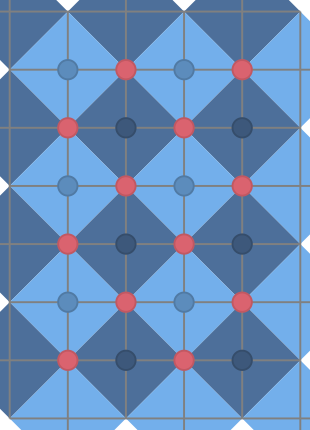

In [2]:
file_path = r'D:\Local-Nobackup\git\qeclibrary\inf_drawing.svg'
drawing = draw_inf_code(file_path)
drawing.saveas(file_path)
drawing

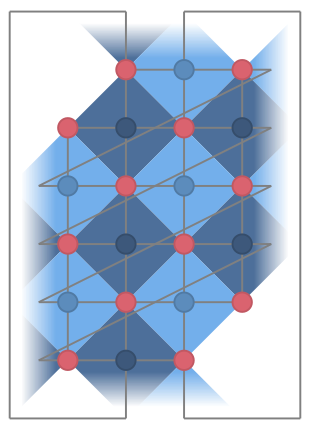

In [3]:
file_path = r'D:\Local-Nobackup\git\qeclibrary\drawing.svg'
drawing = draw_code(file_path)
drawing.saveas(file_path)
drawing

In [4]:
S_X1 = [1,1,1,0,0,1,0,0,0,0,0,0, 0,0,0,0,0,0,0,0,0,0,0,0]
S_X2 = [0,0,1,1,1,0,0,1,0,0,0,0, 0,0,0,0,0,0,0,0,0,0,0,0]
S_X3 = [0,0,0,0,1,1,1,0,0,1,0,0, 0,0,0,0,0,0,0,0,0,0,0,0]
S_X4 = [0,0,0,0,0,0,1,1,1,0,0,1, 0,0,0,0,0,0,0,0,0,0,0,0]
S_X5 = [0,1,0,0,0,0,0,0,1,1,1,0, 0,0,0,0,0,0,0,0,0,0,0,0]
S_Z1 = [0,0,0,0,0,0,0,0,0,0,0,0, 0,1,1,1,0,0,0,0,0,0,1,0]
S_Z2 = [0,0,0,0,0,0,0,0,0,0,0,0, 1,0,0,1,1,1,0,0,0,0,0,0]
S_Z3 = [0,0,0,0,0,0,0,0,0,0,0,0, 0,0,1,0,0,1,1,1,0,0,0,0]
S_Z4 = [0,0,0,0,0,0,0,0,0,0,0,0, 0,0,0,0,1,0,0,1,1,1,0,0]
S_Z5 = [0,0,0,0,0,0,0,0,0,0,0,0, 0,0,0,0,0,0,1,0,0,1,1,1]
stabs = [S_X1, S_X2, S_X3, S_X4, S_X5, S_Z1, S_Z2, S_Z3, S_Z4, S_Z5]
stab_matrix = np.array(stabs)

In [5]:
log_X1 = [1,0,0,0,1,0,0,0,1,0,0,0, 0,0,0,0,0,0,0,0,0,0,0,0]
log_Z1 = [0,0,0,0,0,0,0,0,0,0,0,0, 1,0,1,0,1,0,1,0,1,0,1,0]
log_X2 = [0,0,0,0,0,0,0,0,0,0,0,0, 0,1,0,0,0,1,0,0,0,1,0,0]
log_Z2 = [0,1,0,1,0,1,0,1,0,1,0,1, 0,0,0,0,0,0,0,0,0,0,0,0]
log_ops_manual = [log_X1, log_Z1, log_X2, log_Z2]
centralizer_manual = np.vstack((stab_matrix, log_ops_manual))

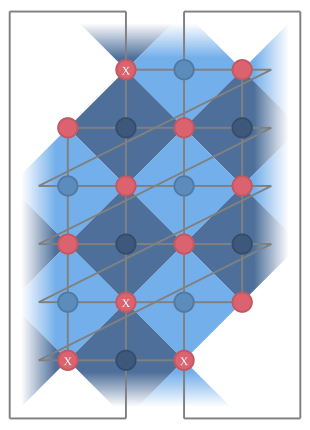

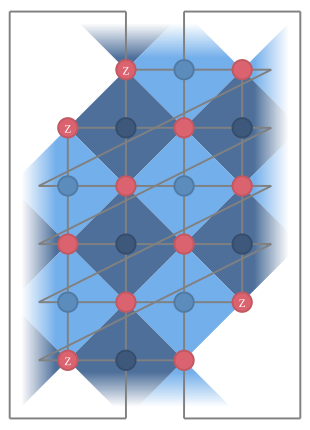

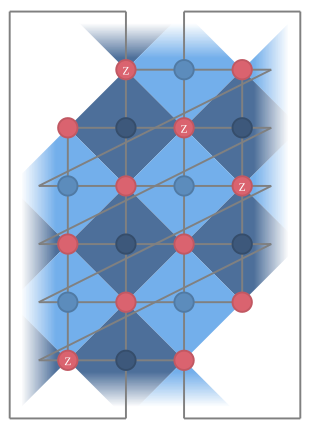

In [6]:
all_ops = cartesian_product_of_sets(generate_group(log_ops_manual), generate_group(stab_matrix))
weight4_ops = [op for op in all_ops if np.sum(op) == 4]
for op in weight4_ops[:3]:
    display(draw_code(file_path, pauli_str=F2_to_xyz(op)))

In [9]:
readout_basis = [1,0,1,0,1,0,1,0,1,0,1,0,0,1,0,1,0,1,0,1,0,1,0,1] # XZ alternatingly
readout_basis_all_X = [1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0] # XZ alternatingly

op2 = [0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
op3 = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1]

def sim_readout(op1, op2):
    n = len(op1) // 2
    for i in range(n):
        if (op1[i] == 1 or op1[i+n] == 1) and (op2[i] == 1 or op2[i+n] == 1):
            if op2[i] != op1[i] or op2[i+n] != op1[i+n]:
                return False
    return True


S = generate_group(stab_matrix)
weights = {}
# for log_op in log_ops_manual:
possible_ops = []
for log_op in [log_X1]:
    for s in S:
        op = (log_op + s) % 2
        # if sim_readout(op, log_op) and sim_readout(op, log_X2) and sim_readout(op, op2) and sim_readout(op, op3):
        if sim_readout(op, readout_basis_all_X):
            weight = np.sum(op)
            if weight not in weights:
                weights[weight] = 0
            weights[weight] += 1
            if weight <= 25:
                print(op)
                possible_ops.append(op)


[0 1 1 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
[0 1 1 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 1 0 1 1 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 1 0 1 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
[1 1 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
[1 1 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 1 0 1 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
[1 0 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 1 1 0 1 1 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
[1 1 0 0 0 1 0 1 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 1 0 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 1 1 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
[1 0 1 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 1 1 0 1 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 1 1 0 1 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[1 0 0 0 1 0 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
[1 1 1 1 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 1 0 1 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
[1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]


In [10]:
ops = generate_group(centralizer_manual)
weights = {}
# for log_op in log_ops_manual:
possible_ops = []
for op in ops:
    if sim_readout(op, readout_basis):
        weight = np.sum(op)
        if weight not in weights:
            weights[weight] = 0
        weights[weight] += 1
        if weight <= 25:
            print(op)
            possible_ops.append(op)

[1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1]
[0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
[1 0 1 0 1 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0]
[1 0 1 0 1 0 1 0 1 0 1 0 0 0 0 1 0 0 0 1 0 0 0 1]
[1 0 1 0 1 0 1 0 1 0 1 0 0 1 0 1 0 1 0 1 0 1 0 1]
[1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 1 0 1 0 1 0 1 0 1]
[0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 1]
[1 0 1 0 1 0 1 0 1 0 1 0 0 1 0 0 0 1 0 0 0 1 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 1 0 1 0 1]
[1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1]
[0 0 1 0 0 0 1 0 0 0 1 0 0 1 0 0 0 1 0 0 0 1 0 0]
[0 0 1 0 0 0 1 0 0 0 1 0 0 1 0 1 0 1 0 1 0 1 0 1]


In [11]:
sim_readout(log_X1, log_X2)
n = len(log_X1) // 2
for i in range(n):
    if (log_X1[i] == 1 or log_X1[i+n] == 1) and (log_X2[i] == 1 or log_X2[i+n] == 1):
        if log_X2[i] != log_X1[i] or log_X2[i+n] == log_X1[i+n]:
            print(i)

In [12]:
# G = compute_centralizer(stab_matrix)
G = centralizer_manual
C = []
Q = []
n = 12
J = symplectic_form(n)
for i in range(len(G)):
    if len(G) == 0:
        break
    g_a = G[0]
    G = G[1:]
    found_anticommuting_el = False
    for j, g_b in enumerate(G):
        if not commute(g_a, g_b):
            found_anticommuting_el = True
            break

    if found_anticommuting_el:
        G = np.vstack((G[0:j], G[j+1:]))
        for k, g_c in enumerate(G):
            x_a = g_c.T @ J @ g_a % 2
            x_b = g_c.T @ J @ g_b % 2
            G[k] = g_c
            if x_a == 1:
                G[k] += g_a
            if x_b == 1:
                G[k] += g_b
            G[k] %= 2
        Q.append(np.array((g_a, g_b)))
    else:
        C.append(g_a)

C = np.array(C)
print(f"{len(C)} commuting elements:")
print(C)
print(f"{len(Q)} pairs of anticommuting elements:")
for pair in Q:
    print(f"{F2_to_xyz(pair[0])} {F2_to_xyz(pair[1])}")

10 commuting elements:
[[1 1 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 1 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 1 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 1 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 1]]
2 pairs of anticommuting elements:
XIIIXIIIXIII ZIZIZIZIZIZI
IZIIIZIIIZII IXIXIXIXIXIX


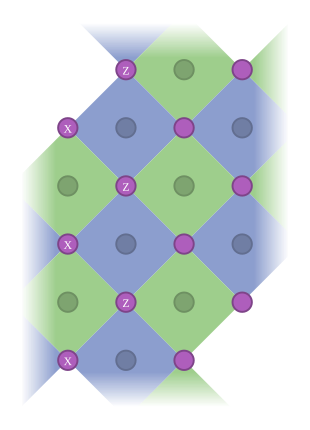

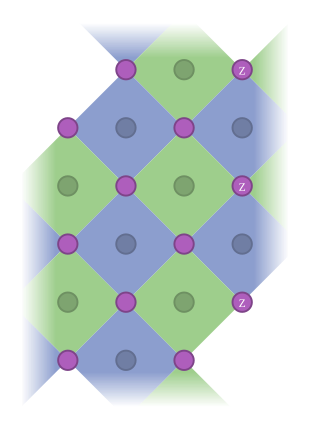

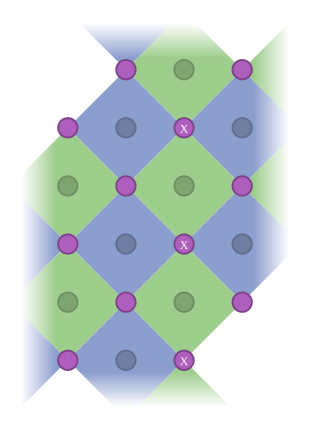

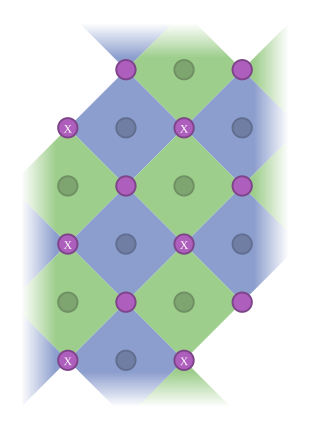

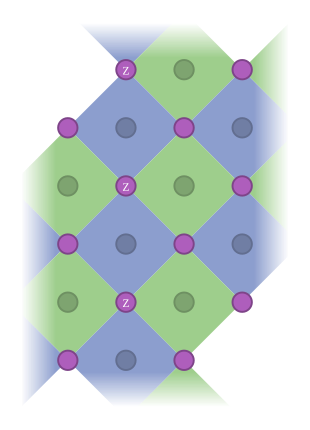

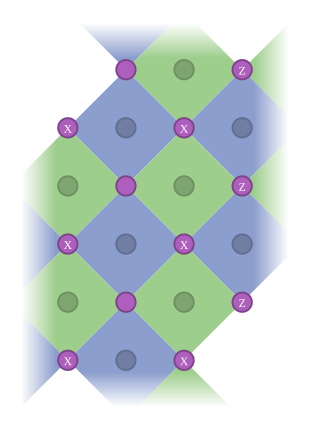

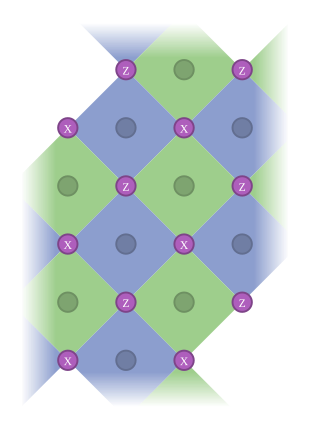

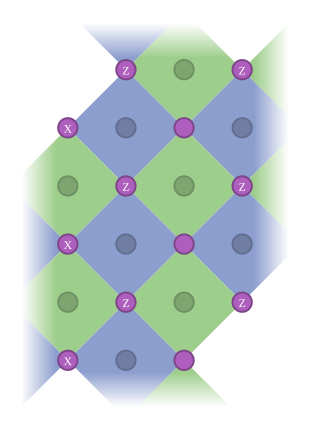

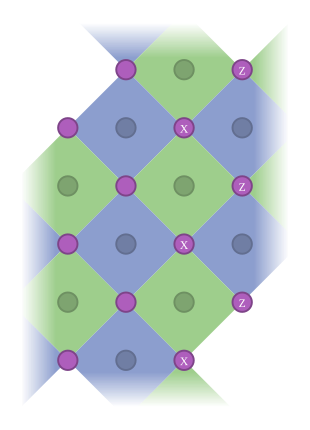

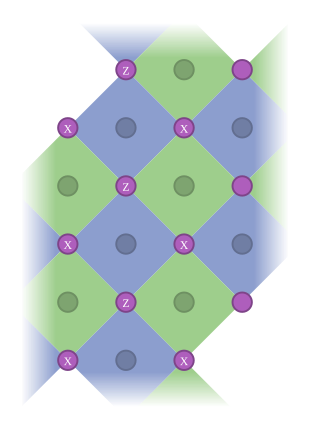

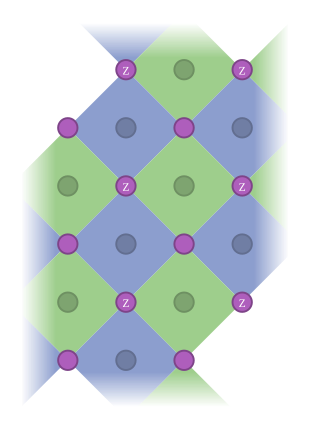

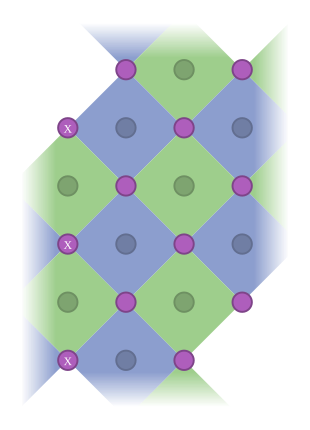

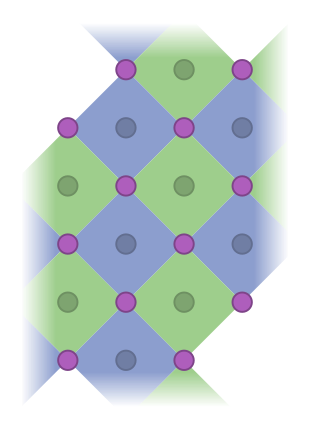

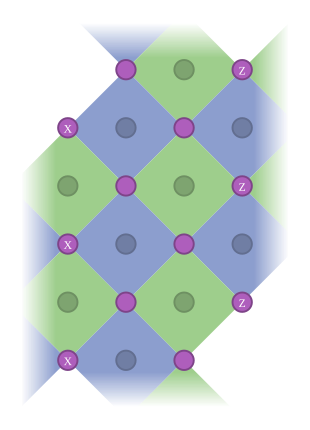

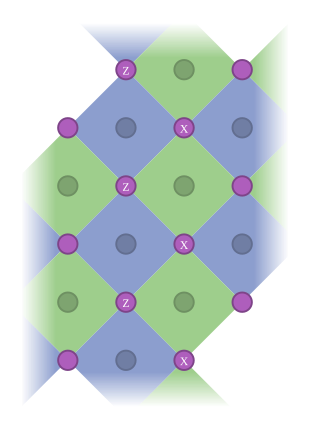

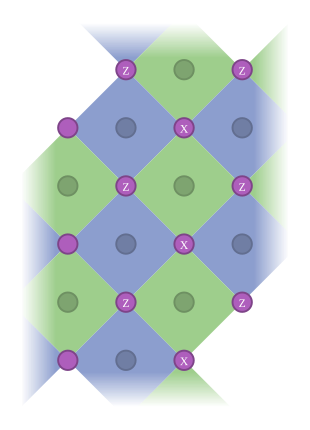

In [13]:
from IPython.display import SVG, display

for i in range(len(possible_ops)):
    display(draw_code(file_path, pauli_str=F2_to_xyz(possible_ops[i])))

In [14]:
log_ops_combined = np.vstack((Q[0][0], Q[0][1], Q[1][0], Q[1][1]))

In [15]:
B = get_log_op_distribution(log_ops_combined, stab_matrix)
print(B)

[1, 0, 0, 16, 45, 144, 776, 1200, 4107, 3248, 4632, 1536, 679]


In [16]:
# A = stabilizer_distribution(stab_matrix)
# print(f"A = {A}")
# B = get_log_op_distribution(log_ops, stab_matrix)
# print(f"B = {B}")

In [5]:
def get_syndrome_circuit(stabilizers, n_cycles: int = 1, n_qubits: int = 0, prep_basis: str = "", qb_coords: dict = None, incl_det_ids: list[int] = None, mode: str = "parallel"):
    if incl_det_ids is None:
        incl_det_ids = list(range(len(stabilizers)))
    def get_qb_coord(i):
        if qb_coords is None:
            return i
        else:
            return f"{qb_coords[i][0]}, {qb_coords[i][1]}"
    ancilla_qbs = [stab[2] for stab in stabilizers]
    max_stab_length = 0
    for stab in stabilizers:
        max_stab_length = max(max_stab_length, len(stab[0]))

    circuit_list = []
    for qec_cycle in range(n_cycles):
        circuit_list += (
            ("H", [id for id in ancilla_qbs]),
            ("Barrier", []),
        )

        if mode == "sequential":
            for stab in stabilizers:
                for step in range(max_stab_length):
                    if stab[0][step] != "I":
                        circuit_list += (
                            (
                                f"C{stab[0][step]}",
                                [
                                    stab[2],
                                    stab[1][step],
                                ],
                            ),
                        )
                circuit_list += (
                    ("H", stab[2]),
                    ("MR", stab[2]),
                    ("Barrier", []),
                )
        elif mode == "parallel":
            for step in range(max_stab_length):
                for stab in stabilizers:
                    if stab[0][step] != "I":
                        circuit_list += (
                            (
                                f"C{stab[0][step]}",
                                [
                                    stab[2],
                                    stab[1][step],
                                ],
                            ),
                        )
                circuit_list += (("Barrier", []),)

            circuit_list += (
                ("H", ancilla_qbs),
                ("MR", ancilla_qbs),
            )

        # Create detectors
        if qec_cycle >= 1:
            circuit_list += [
                ("DETECTOR", [f"rec[{-len(stabilizers)*2 + i}]", f"rec[{-len(stabilizers) + i}]"], f"{get_qb_coord(stabilizers[i][2])}, {qec_cycle}")
                for i in range(len(stabilizers))
                if i in incl_det_ids
            ]
        if qec_cycle == 0:
            circuit_list += [
                ("DETECTOR", [f"rec[{-len(stabilizers) + i}]"], f"{get_qb_coord(stabilizers[i][2])}, {qec_cycle}")
                for i in range(len(stabilizers))
                if prep_basis != "" and sim_readout(stab_to_F2([stabilizers[i]], n_qubits)[0], stab_to_F2([[prep_basis, range(n_qubits), None]], n_qubits)[0])
                and i in incl_det_ids
            ]
        circuit_list += (
            ("Barrier", []),
        )

    return circuit_list

In [6]:
# Order: Top, right, bottom, left
stabilizers_22_TT_generic = [
    ["XXXX", [1,2,5,0], 12], # SX1
    ["XXXX", [3,4,7,2], 13], # SX2
    ["XXXX", [5,6,9,4], 14], # SX3
    ["XXXX", [7,8,11,6], 15], # SX4
    ["XXXX", [9,10,1,8], 16], # SX5
    ["ZZZZ", [10,3,2,1], 17], # SZ1
    ["ZZZZ", [0,5,4,3], 18], # SZ2
    ["ZZZZ", [2,7,6,5], 19], # SZ3
    ["ZZZZ", [4,9,8,7], 20], # SZ4
    ["ZZZZ", [6,11,10,9], 21], # SZ5
]
stabilizers_24_TT_generic = [
    ["XXXX", [1,2,5,0], 12], # SX1
    ["XXXX", [3,4,7,2], 13], # SX2
    ["XXXX", [5,6,9,4], 14], # SX3
    ["XXXX", [7,8,11,6], 15], # SX4
    ["XXXX", [9,10,1,8], 16], # SX5
    ["XXXX", [11,0,3,10], 17], # SX6
    ["ZZZZ", [10,3,2,1], 18], # SZ1
    ["ZZZZ", [0,5,4,3], 19], # SZ2
    ["ZZZZ", [2,7,6,5], 20], # SZ3
    ["ZZZZ", [4,9,8,7], 21], # SZ4
    ["ZZZZ", [6,11,10,9], 22], # SZ5
    ["ZZZZ", [8,1,0,11], 23], # SZ6
]
stabilizers_22_TT = [
    ["XXXX", [1,0,2,5], 12], # SX1
    ["XXXX", [3,2,4,7], 13], # SX2
    ["XXXX", [5,4,6,9], 14], # SX3
    ["XXXX", [7,6,8,11], 15], # SX4
    ["XXXX", [9,8,10,1], 16], # SX5
    ["ZZZZ", [2,1,3,10], 17], # SZ1
    ["ZZZZ", [4,3,5,0], 18], # SZ2
    ["ZZZZ", [6,5,7,2], 19], # SZ3
    ["ZZZZ", [8,7,9,4], 20], # SZ4
    ["ZZZZ", [10,9,11,6], 21], # SZ5
]
stab_matrix_22_TT = stab_to_F2(stabilizers_22_TT, 12)
def order_stabs(stabs, order = [0, 1, 2, 3]):
    if isinstance(order[0], int):
        order = [order for _ in range(len(stabs))]
    return [
        [stab[0], [stab[1][order[i][0]], stab[1][order[i][1]], stab[1][order[i][2]], stab[1][order[i][3]]], stab[2]]
        for i, stab in enumerate(stabs)
    ]

# Surface 17
stabilizers_surf_17 = [
    ["IIXX", [None,None,2,1], 9], # SX1
    ["XXXX", [1,0,4,3], 10], # SX2
    ["XXXX", [5,4,8,7], 11], # SX3
    ["XXII", [7,6,None,None], 12], # SX4
    ["ZZII", [0,3,None,None], 13], # SZ1
    ["ZZZZ", [4,7,3,6], 14], # SZ2
    ["ZZZZ", [2,5,1,4], 15], # SZ3
    ["IIZZ", [None,None,5,8], 16], # SZ4
]
# Hand drawing pdf: WRONG schedule!!!!!!!!!!! (N/Z schedule is exactly the wrong way round)
stabilizers_surf_17_wrong = [
    ["IXIX", [None,1,None,2], 9], # SX1
    ["XXXX", [0,3,1,4], 10], # SX2
    ["XXXX", [4,7,5,8], 11], # SX3
    ["XIXI", [6,None,7,None], 12], # SX4
    ["IZIZ", [None,0,None,3], 13], # SZ1
    ["ZZZZ", [3,4,6,7], 14], # SZ2
    ["ZZZZ", [1,2,4,5], 15], # SZ3
    ["ZIZI", [5,None,8,None], 16], # SZ4
]
# Hand drawing pdf: Right schedule
stabilizers_surf_17 = [
    ["IIXX", [None,None,1,2], 9], # SX1
    ["XXXX", [0,1,3,4], 10], # SX2
    ["XXXX", [4,5,7,8], 11], # SX3
    ["XXII", [6,7,None,None], 12], # SX4
    ["IIZZ", [None,None,0,3], 13], # SZ1
    ["ZZZZ", [3,6,4,7], 14], # SZ2
    ["ZZZZ", [1,4,2,5], 15], # SZ3
    ["ZZII", [5,8,None,None], 16], # SZ4
]
stab_matrix_surf_17 = stab_to_F2(stabilizers_surf_17, 9)

In [48]:
import stim
import importlib
import qeclib
from qeclib import convert_to_stim
from qeclib import PauliNoiseModel

def get_circ(stabilizers, n, n_qec_rounds, init_state, measure_op, qb_coords, incl_det_ids, stab_ext_mode):
    measure_op_F2 = stab_to_F2([[measure_op, range(n), None]], n)

    circ = []
    if init_state == "ZZ":
        circ += []
    elif init_state == "XX":
        circ += [
            ("H", range(n)),
        ]
    else:
        raise ValueError("Invalid initial state")
    circ += [("Barrier", [])]
    circ += get_syndrome_circuit(stabilizers, n_qec_rounds, n_qubits=n, prep_basis=measure_op, qb_coords=qb_coords, incl_det_ids=incl_det_ids, mode=stab_ext_mode)

    if "X" in measure_op:
        circ += [("MX", [i for i in range(len(measure_op)) if measure_op[i] == "X"])]
    if "Y" in measure_op:
        circ += [("MY", [i for i in range(len(measure_op)) if measure_op[i] == "Y"])]
    if "Z" in measure_op:
        circ += [("M", [i for i in range(len(measure_op)) if measure_op[i] == "Z"])]

    for stab_index, stab in enumerate(stabilizers):
        if sim_readout(stab_to_F2([stab], n)[0], measure_op_F2[0]) and stab_index in incl_det_ids:
            circ += [("DETECTOR", [f"rec[{-n+stab[1][i]}]" for i in range(len(stab[1])) if stab[0][i] != "I"] + [f"rec[{-n-len(stabilizers) + stab_index}]"], f"{qb_coords[stab[2]][0]}, {qb_coords[stab[2]][1]}, {n_qec_rounds}")]

    circ += [("OBSERVABLE_INCLUDE", [f"rec[{-n+i}]" for i in range(len(log_op)) if log_op[i] != "I"], 0)]

    return circ

def get_stim_circ(stabilizers, n, n_qec_rounds, init_state, measure_op, qb_coords, incl_det_ids, stab_ext_mode):
    circ = get_circ(stabilizers, n, n_qec_rounds, init_state, measure_op, qb_coords, incl_det_ids, stab_ext_mode)
    noise_model = PauliNoiseModel(0.01)
    stim_circ = qeclib.convert_to_stim(circ, qb_coords, noise_model)
    return stim.Circuit(stim_circ)

In [49]:
stabilizers = order_stabs(stabilizers_22_TT_generic, [(0,2,1,3) for _ in range(5)] + [(1,3,0,2) for _ in range(5)]) # Works but d=3
print(stabilizers)

[['XXXX', [1, 5, 2, 0], 12], ['XXXX', [3, 7, 4, 2], 13], ['XXXX', [5, 9, 6, 4], 14], ['XXXX', [7, 11, 8, 6], 15], ['XXXX', [9, 1, 10, 8], 16], ['ZZZZ', [3, 1, 10, 2], 17], ['ZZZZ', [5, 3, 0, 4], 18], ['ZZZZ', [7, 5, 2, 6], 19], ['ZZZZ', [9, 7, 4, 8], 20], ['ZZZZ', [11, 9, 6, 10], 21]]


In [50]:
import copy

def stretch_syndrome_circuit(stabilizers):
    new_stabilizers = [["", [], stab[2]] for stab in stabilizers]
    max_stab_length = 0
    for stab in stabilizers:
        max_stab_length = max(max_stab_length, len(stab[0]))

    for i in range(max_stab_length):
        stabs_to_process = set((stab[0], tuple(stab[1]), stab[2]) for stab in stabilizers)
        while len(stabs_to_process) > 0:
            qbs_used = []
            for stab_id, stab in enumerate(stabilizers):
                stab = (stab[0], tuple(stab[1]), stab[2])
                if stab in stabs_to_process and (stab[1][i] is None or (stab[1][i] not in qbs_used and stab[2] not in qbs_used)):
                    new_stabilizers[stab_id][0] += stab[0][i]
                    new_stabilizers[stab_id][1].append(stab[1][i])
                    qbs_used.append(stab[1][i])
                    stabs_to_process = stabs_to_process - {stab}
                else:
                    new_stabilizers[stab_id][0] += "I"
                    new_stabilizers[stab_id][1].append(None)

    return new_stabilizers

Code distance d = 1


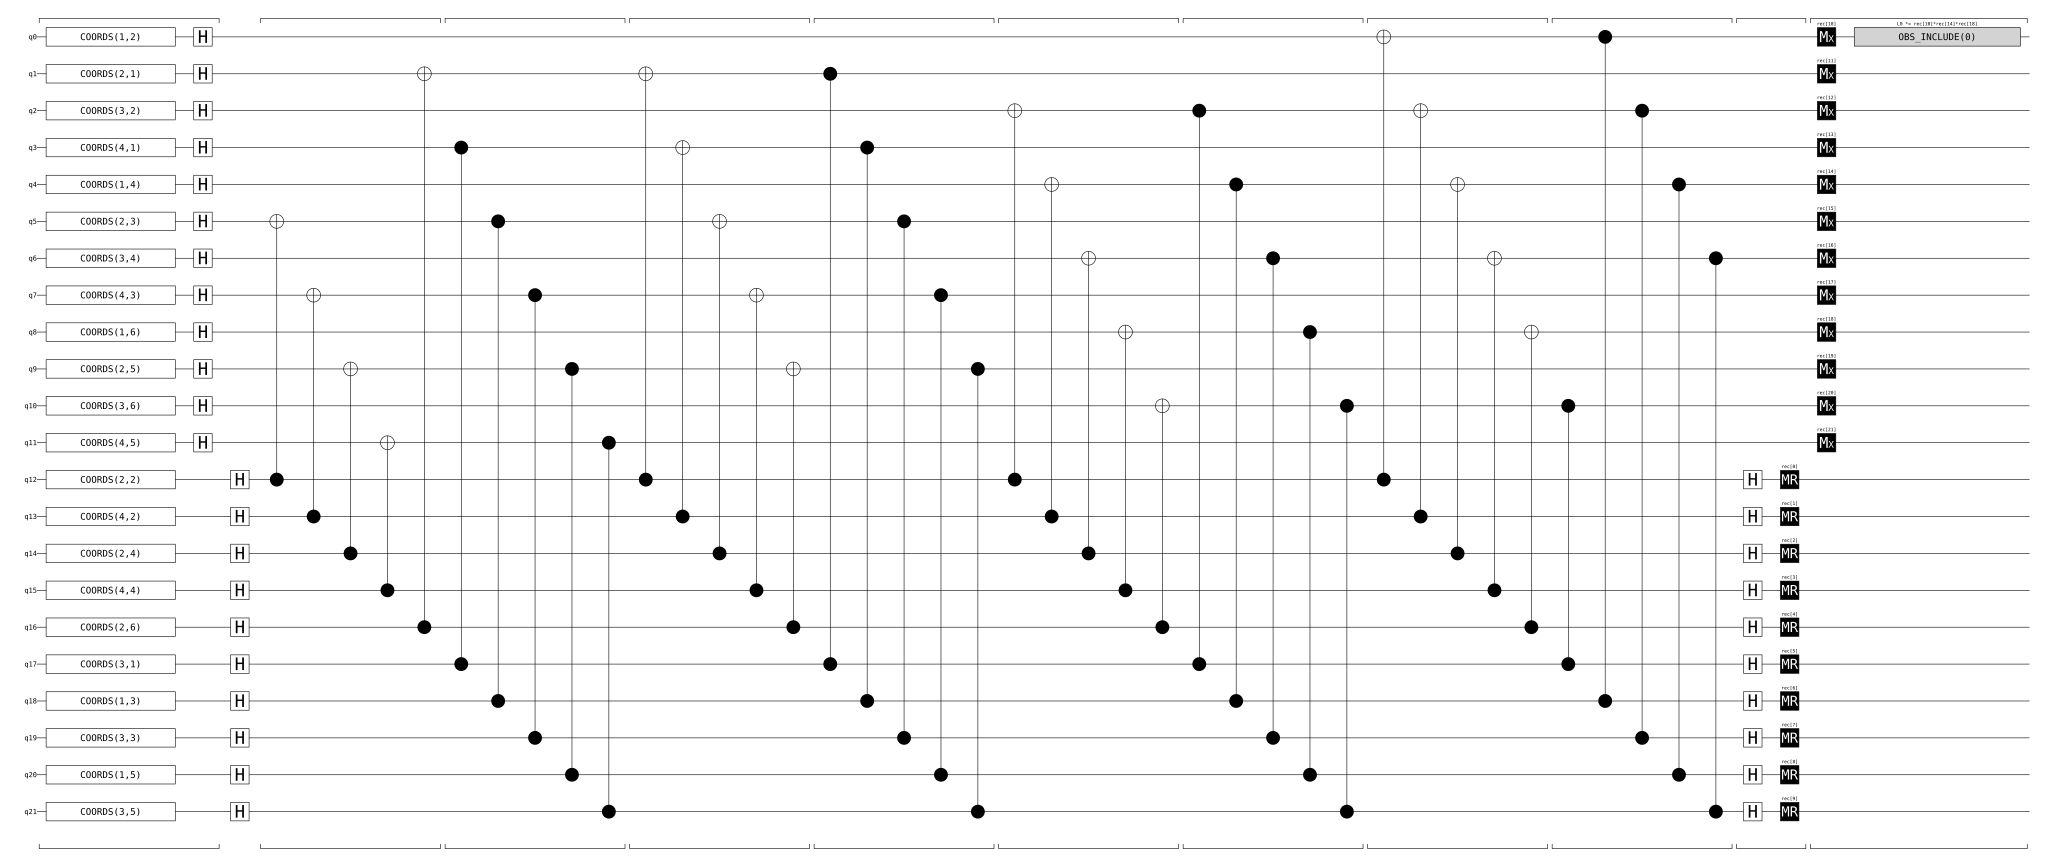

In [51]:
code = "22TT"
n_qec_rounds = 3
stab_ext_mode = "parallel"
# stab_ext_mode = "sequential"

if code == "22TT":
    valid_orders = {
        0: [(0, 2, 1, 3) for _ in range(5)] + [(1, 3, 0, 2) for _ in range(5)],
        1: [(0, 2, 3, 1) for _ in range(5)] + [(3, 1, 0, 2) for _ in range(5)],
        2: [(1, 3, 0, 2) for _ in range(5)] + [(0, 2, 1, 3) for _ in range(5)],
        3: [(1, 3, 2, 0) for _ in range(5)] + [(2, 0, 1, 3) for _ in range(5)],
        4: [(2, 0, 1, 3) for _ in range(5)] + [(1, 3, 2, 0) for _ in range(5)],
        5: [(2, 0, 3, 1) for _ in range(5)] + [(3, 1, 2, 0) for _ in range(5)],
        6: [(3, 1, 0, 2) for _ in range(5)] + [(0, 2, 3, 1) for _ in range(5)],
        7: [(3, 1, 2, 0) for _ in range(5)] + [(2, 0, 3, 1) for _ in range(5)],
    }
    n = 12
    stabilizers = stabilizers_22_TT
    # stabilizers = order_stabs(stabilizers_22_TT_generic, [0,1,3,2]) # Works but d=2
    stabilizers = order_stabs(stabilizers_22_TT_generic, [0,3,1,2]) # Works but d=2
    stabilizers = order_stabs(stabilizers_22_TT_generic, [[0,3,1,2] for _ in range(5)] + [[0,1,3,2] for _ in range(5)]) # Works but d=2
    stabilizers = order_stabs(stabilizers_22_TT_generic, [[0,1,3,2] for _ in range(5)] + [[0,3,1,2] for _ in range(5)]) # Works but d=2
    stabilizers = order_stabs(stabilizers_22_TT_generic, [[1,0,2,3] for _ in range(5)] + [[1,2,0,3] for _ in range(5)]) # Works but d=2
    stabilizers = order_stabs(stabilizers_22_TT_generic, [(0,2,1,3) for _ in range(5)] + [(1,3,0,2) for _ in range(5)]) # Works but d=3
    # stabilizers = order_stabs(stabilizers_22_TT_generic, [(3, 1, 2, 0) for _ in range(5)] + [(2, 0, 3, 1) for _ in range(5)]) # d=3 but not parallelizable
    stabilizers = stretch_syndrome_circuit(order_stabs(stabilizers_22_TT_generic, valid_orders[4]))
    stabilizers = [
        ['XIXIXIXI', [5, None, 1, None, 2, None, 0, None], 12],
        ['XIXIXIXI', [7, None, 3, None, 4, None, 2, None], 13],
        ['XIXIXIXI', [9, None, 5, None, 6, None, 4, None], 14],
        ['XIXIXIXI', [11, None, 7, None, 8, None, 6, None], 15],
        ['XIXIXIXI', [1, None, 9, None, 10, None, 8, None], 16],
        ['IZIZIZIZ', [None, 3, None, 1, None, 2, None, 10], 17],
        ['IZIZIZIZ', [None, 5, None, 3, None, 4, None, 0], 18],
        ['IZIZIZIZ', [None, 7, None, 5, None, 6, None, 2], 19],
        ['IZIZIZIZ', [None, 9, None, 7, None, 8, None, 4], 20],
        ['IZIZIZIZ', [None, 11, None, 9, None, 10, None, 6], 21]
        ]
    # stabilizers = order_stabs(stabilizers_22_TT_generic, [1,0,2,3]) # Works but d=2
    # stabilizers = order_stabs(stabilizers_22_TT_generic, [1,2,0,3]) # Works but d=2
    incl_det_ids = range(len(stabilizers))
    # incl_det_ids = [0]
    qb_coords = {}
    for qb, coord in qubit_positions.items():
        qb_id = int(qb[1:]) - 1
        if qb[0] == "X":
            qb_id += 12
        if qb[0] == "Z":
            qb_id += 17
        qb_coords[qb_id] = (coord[0], coord[1])
    measure_op = "XXXXXXXXXXXX"
    log_op = "XIIIXIIIXIII"
elif code == "24TT":
    n = 12
    stabilizers = order_stabs(stabilizers_24_TT_generic, [0,3,1,2]) # Works but d=2
    stabilizers = order_stabs(stabilizers_24_TT_generic, [1,0,2,3]) # d=3 !!!
    incl_det_ids = range(len(stabilizers))
    qb_coords = {}
    for qb, coord in qubit_positions_24.items():
        qb_id = int(qb[1:]) - 1
        if qb[0] == "X":
            qb_id += 12
        if qb[0] == "Z":
            qb_id += 18
        qb_coords[qb_id] = (coord[0], coord[1])
    measure_op = "XXXXXXXXXXXX"
    log_op = "XIIIXIIIXIII"
elif code == "surf17":
    n = 9
    stabilizers = stabilizers_surf_17
    incl_det_ids = [4,5,6,7]
    qb_coords = {
        0: (1, 1),
        1: (2, 1),
        2: (3, 1),
        3: (1, 2),
        4: (2, 2),
        5: (3, 2),
        6: (1, 3),
        7: (2, 3),
        8: (3, 3),
        9: (2.5, 0.5), # S_X1
        10: (1.5, 1.5), # S_X2
        11: (2.5, 2.5), # S_X3
        12: (1.5, 3.5), # S_X4
        13: (0.5, 1.5), # S_Z1
        14: (1.5, 2.5), # S_Z2
        15: (2.5, 1.5), # S_Z3
        16: (3.5, 2.5), # S_Z4
    }
    # measure_op = "XXXXXXXXX"
    measure_op = "ZZZZZZZZZ"
    log_op = "ZZZIIIIII"

circ = get_circ(stabilizers, n, n_qec_rounds, "XX", measure_op, qb_coords, incl_det_ids, stab_ext_mode)
stim_circ = get_stim_circ(stabilizers, n, 1, "XX", measure_op, qb_coords, incl_det_ids=[], stab_ext_mode=stab_ext_mode)
# print(stim_circ)
dem = stim_circ.detector_error_model()
print(f"Code distance d = {len(stim_circ.detector_error_model().shortest_graphlike_error())}")
stim_circ.without_noise().diagram(type="timeline-svg")

# dem = stim_circ.detector_error_model()
# print(f"Code distance d = {len(stim_circ.detector_error_model().shortest_graphlike_error())}")
# dem.shortest_graphlike_error()


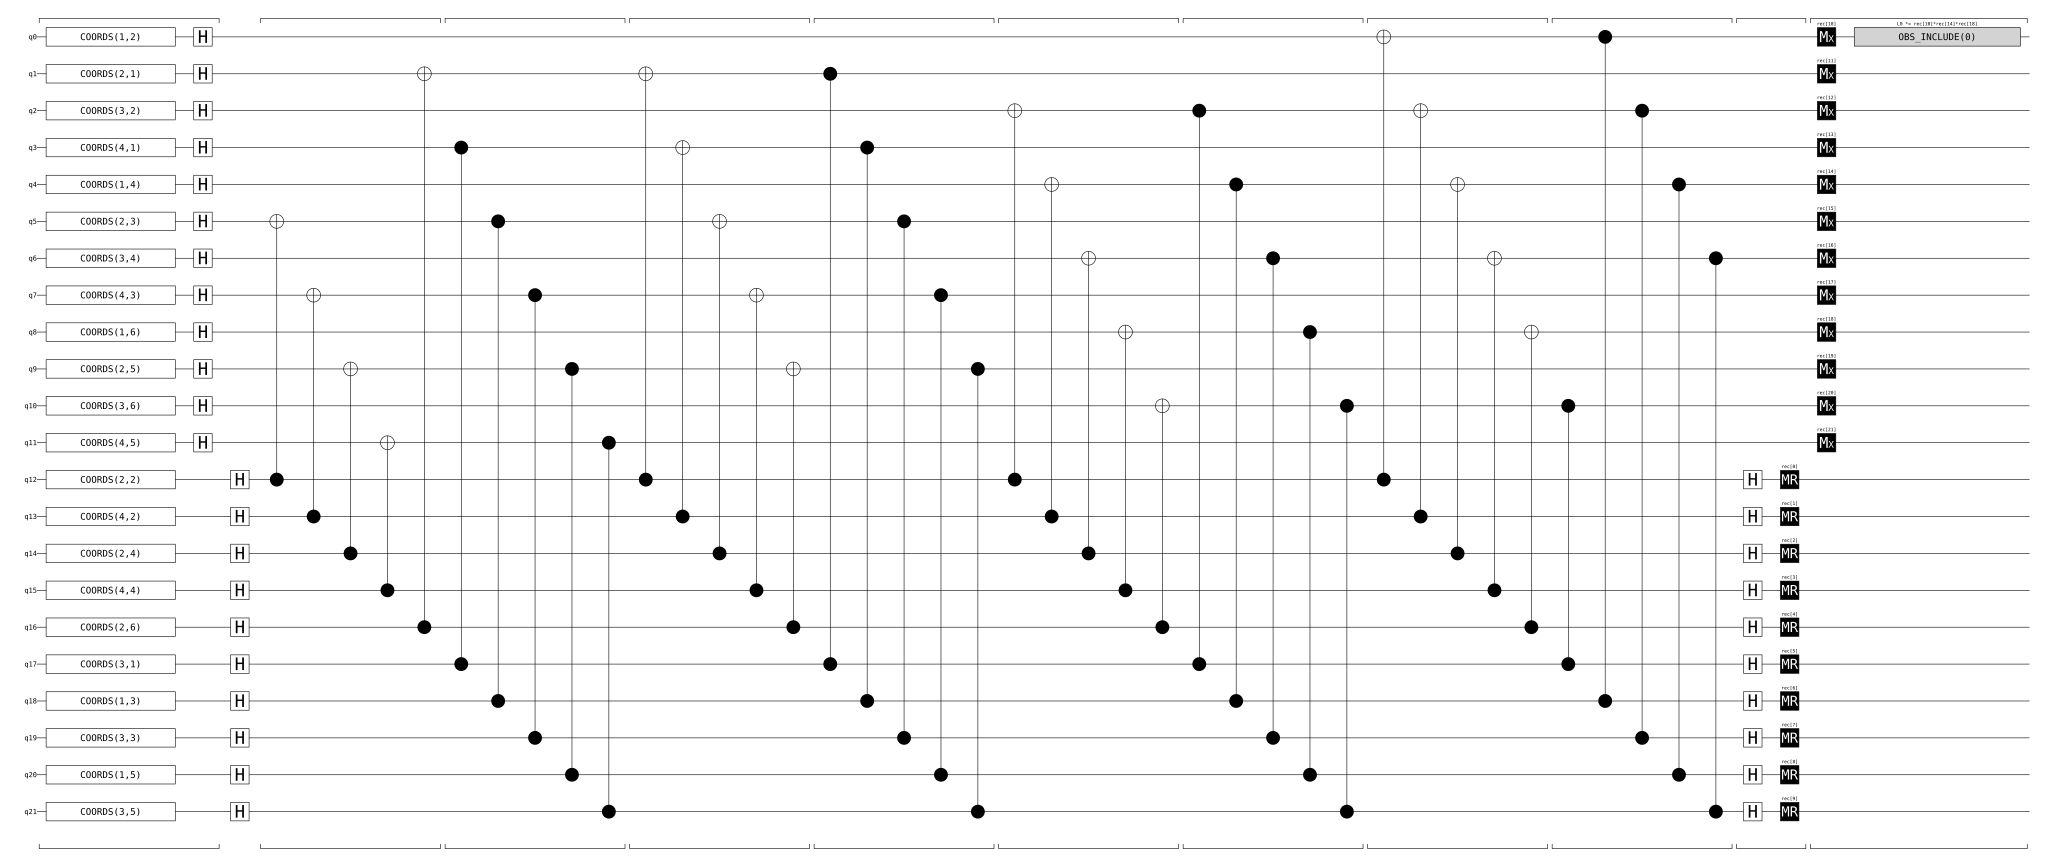

In [52]:
# stim_circ.diagram("detslice-svg")
stim_circ.without_noise().diagram(type="timeline-svg")

In [12]:
dem = stim_circ.detector_error_model()
print(f"Code distance d = {len(stim_circ.detector_error_model().shortest_graphlike_error())}")
dem.shortest_graphlike_error()

Code distance d = 3


stim.DetectorErrorModel('''
    error(1) D0 D1
    error(1) D0 L0
    error(1) D1
''')

In [13]:
print(stim_circ.explain_detector_error_model_errors(dem_filter = dem.shortest_graphlike_error(), reduce_to_one_representative_error=True,)[0])

ExplainedError {
    dem_error_terms: D0[coords 2,2,0] D1[coords 4,2,0]
    CircuitErrorLocation {
        flipped_pauli_product: Z2[coords 3,2]
        Circuit location stack trace:
            (after 0 TICKs)
            at instruction #24 (DEPOLARIZE1) in the circuit
            at target #3 of the instruction
            resolving to DEPOLARIZE1(0.01) 2[coords 3,2]
    }
}


In [14]:
for err in stim_circ.search_for_undetectable_logical_errors(dont_explore_detection_event_sets_with_size_above=999, dont_explore_edges_with_degree_above=999, dont_explore_edges_increasing_symptom_degree=False):
    print(err)

ExplainedError {
    dem_error_terms: D0[coords 2,2,0] D1[coords 4,2,0]
    CircuitErrorLocation {
        flipped_pauli_product: Z12[coords 2,2]*Z2[coords 3,2]
        Circuit location stack trace:
            (after 5 TICKs)
            at instruction #78 (DEPOLARIZE2) in the circuit
            at targets #1 to #2 of the instruction
            resolving to DEPOLARIZE2(0.01) 12[coords 2,2] 2[coords 3,2]
    }
    CircuitErrorLocation {
        flipped_pauli_product: Z12[coords 2,2]*Y2[coords 3,2]
        Circuit location stack trace:
            (after 5 TICKs)
            at instruction #78 (DEPOLARIZE2) in the circuit
            at targets #1 to #2 of the instruction
            resolving to DEPOLARIZE2(0.01) 12[coords 2,2] 2[coords 3,2]
    }
    CircuitErrorLocation {
        flipped_pauli_product: Y12[coords 2,2]*Z2[coords 3,2]
        Circuit location stack trace:
            (after 5 TICKs)
            at instruction #78 (DEPOLARIZE2) in the circuit
            at targets #1

In [15]:
dem.diagram("matchgraph-3d-html")

<!DOCTYPE html>
<html>
<head>
  <meta charset="UTF-8" />
  <script type="importmap">
    {
      "imports": {
        "three": "https://unpkg.com/three@0.138.0/build/three.module.js",
        "three-orbitcontrols": "https://unpkg.com/three@0.138.0/examples/jsm/controls/OrbitControls.js",
        "three-gltf-loader": "https://unpkg.com/three@0.138.0/examples/jsm/loaders/GLTFLoader.js"
      }
    }
  </script>
</head>
<body>
  <a download="model.gltf" id="stim-3d-viewer-download-link" href="data:text/plain;base64,eyJhY2Nlc3NvcnMiOlt7ImJ1ZmZlclZpZXciOjAsImJ5dGVPZmZzZXQiOjAsImNvbXBvbmVudFR5cGUiOjUxMjYsImNvdW50IjoxNywibWF4IjpbMCwwLjQwMDAwMDAwNTk2MDQ2NCwwLjQwMDAwMDAwNTk2MDQ2NF0sIm1pbiI6WzAsLTAuNDAwMDAwMDA1OTYwNDY0LC0wLjQwMDAwMDAwNTk2MDQ2NF0sIm5hbWUiOiJjaXJjbGVfbG9vcCIsInR5cGUiOiJWRUMzIn0seyJidWZmZXJWaWV3IjoxLCJieXRlT2Zmc2V0IjowLCJjb21wb25lbnRUeXBlIjo1MTI2LCJjb3VudCI6MjU4LCJtYXgiOlsyMS4wNDUzNDE0OTE2OTkyLDI3LjYyMjUwNTE4Nzk4ODMsMTUuODgyNDcyMDM4MjY5XSwibWluIjpbLTYuMDQ1MzQxNDkxNjk5MjIsLTYuNjIyNTA1MTg3OTg4MjgsLTYuODgyNDcyMDM4MjY5MDRdLCJuYW1lIjoiYnVmX3NjYXR0ZXJlZF9saW5lcyIsInR5cGUiOiJWRUMzIn0seyJidWZmZXJWaWV3IjoyLCJieXRlT2Zmc2V0IjowLCJjb21wb25lbnRUeXBlIjo1MTI2LCJjb3VudCI6NDYsIm1heCI6WzEyLDE4LDE1Ljg4MjQ3MjAzODI2OV0sIm1pbiI6WzIuOTg0ODg2NjQ2MjcwNzUsLTMuMDQ1MzQxNDkxNjk5MjIsLTYuODgyNDcyMDM4MjY5MDRdLCJuYW1lIjoiYnVmX3JlZF9zY2F0dGVyZWRfbGluZXMiLCJ0eXBlIjoiVkVDMyJ9LHsiYnVmZmVyVmlldyI6MywiYnl0ZU9mZnNldCI6MCwiY29tcG9uZW50VHlwZSI6NTEyNiwiY291bnQiOjI2ODYsIm1heCI6WzEyLDE4LDldLCJtaW4iOlszLDMsMF0sIm5hbWUiOiJidWZfYmx1ZV9zY2F0dGVyZWRfbGluZXMiLCJ0eXBlIjoiVkVDMyJ9XSwiYXNzZXQiOnsidmVyc2lvbiI6IjIuMCJ9LCJidWZmZXJWaWV3cyI6W3siYnVmZmVyIjowLCJieXRlTGVuZ3RoIjoyMDQsImJ5dGVPZmZzZXQiOjAsIm5hbWUiOiJjaXJjbGVfbG9vcCIsInRhcmdldCI6MzQ5NjJ9LHsiYnVmZmVyIjoxLCJieXRlTGVuZ3RoIjozMDk2LCJieXRlT2Zmc2V0IjowLCJuYW1lIjoiYnVmX3NjYXR0ZXJlZF9saW5lcyIsInRhcmdldCI6MzQ5NjJ9LHsiYnVmZmVyIjoyLCJieXRlTGVuZ3RoIjo1NTIsImJ5dGVPZmZzZXQiOjAsIm5hbWUiOiJidWZfcmVkX3NjYXR0ZXJlZF9saW5lcyIsInRhcmdldCI6MzQ5NjJ9LHsiYnVmZmVyIjozLCJieXRlTGVuZ3RoIjozMjIzMiwiYnl0ZU9mZnNldCI6MCwibmFtZSI6ImJ1Zl9ibHVlX3NjYXR0ZXJlZF9saW5lcyIsInRhcmdldCI6MzQ5NjJ9XSwiYnVmZmVycyI6W3siYnl0ZUxlbmd0aCI6MjA0LCJuYW1lIjoiY2lyY2xlX2xvb3AiLCJ1cmkiOiJkYXRhOmFwcGxpY2F0aW9uL29jdGV0LXN0cmVhbTtiYXNlNjQsQUFBQUFNM016RDRBQUFBQUFBQUFBT1UxdlQ1RnZ4dytBQUFBQU1QUWtEN0QwSkErQUFBQUFFUy9IRDdsTmIwK0FBQUFBUEl3bHJMTnpNdytBQUFBQUVlL0hMN2xOYjArQUFBQUFNUFFrTDdEMEpBK0FBQUFBT2MxdmI1QXZ4dytBQUFBQU0zTXpMN3lNQmF6QUFBQUFPVTF2YjVFdnh5K0FBQUFBTUhRa0w3RTBKQytBQUFBQUR5L0hMN25OYjIrQUFBQUFQTGtvekhOek15K0FBQUFBRW0vSEQ3a05iMitBQUFBQU1iUWtENi8wSkMrQUFBQUFPWTF2VDVFdnh5K0FBQUFBTTNNekQ0QUFBQUEifSx7ImJ5dGVMZW5ndGgiOjMwOTYsIm5hbWUiOiJidWZfc2NhdHRlcmVkX2xpbmVzIiwidXJpIjoiZGF0YTphcHBsaWNhdGlvbi9vY3RldC1zdHJlYW07YmFzZTY0LEFBREFRQUFBd0VBQUFBQUFBQUJBUVFBQXdFQUFBQUFBQUFEQVFBQUF3RUFBQUFBQUFBREFRQUFBUUVFQUFBQUFBQURBUUFBQXdFQUFBQUFBQUFEQVFBQUFrRUVBQUFBQUFBREFRQUFBd0VBQUFBQUFBQURBUUFBQXdFQUFBRUJBQUFEQVFBQUF3RUFBQUFBQUFBREFRQUFBa0VFQUFFQkFBQUJBUVFBQXdFQUFBQUFBSWpDT1FRRHZaejZJd0xqQUFBQkFRUUFBd0VBQUFBQUFBQUJBUVFBQVFFRUFBQUFBQUFCQVFRQUF3RUFBQUFBQUFBREFRQUFBd0VBQUFFQkFBQUJBUVFBQXdFQUFBQUFBQUFCQVFRQUF3RUFBQUVCQUFBQkFRUUFBd0VBQUFBQUFBQUFRUVFBQVFFQUFBRUJBQUFEQVFBQUFRRUVBQUFBQUFBQkFRUUFBUUVFQUFBQUFBQURBUUFBQVFFRUFBQUFBQUFEQVFBQUFrRUVBQUFBQUFBREFRQUFBUUVFQUFBQUFBQURBUUFBQXdFQUFBRUJBQUFEQVFBQUFRRUVBQUFBQUFBREFRQUFBUUVFQUFFQkFBQUJBUVFBQVFFRUFBQUFBVGcrWFFkNjBaRUUyUGR6QUFBQkFRUUFBUUVFQUFBQUFBQUJBUVFBQXdFQUFBRUJBQUFCQVFRQUFRRUVBQUFBQUFBREFRQUFBUUVFQUFFQkFBQUJBUVFBQVFFRUFBQUFBQUFCQVFRQUFRRUVBQUVCQUFBREFRQUFBa0VFQUFBQUEvdWlKUU1LYzAwRUZSYUxBQUFEQVFBQUFrRUVBQUFBQUFBREFRQUFBUUVFQUFFQkFBQURBUUFBQWtFRUFBQUFBQUFEQVFBQUFrRUVBQUVCQUFBREFRQUFBa0VFQUFBQUFBQUJBUUFBQWNFRUFBRUJBQUFEQVFBQUF3RUFBQUVCQUFBQkFRUUFBd0VBQUFFQkFBQURBUUFBQXdFQUFBRUJBQUFEQVFBQUFRRUVBQUVCQUFBREFRQUFBd0VBQUFFQkFBQURBUUFBQWtFRUFBRUJBQUFEQVFBQUF3RUFBQUVCQUFBREFRQUFBd0VBQUFNQkFBQURBUUFBQXdFQUFBRUJBQUFEQVFBQUFrRUVBQU1CQUFBQkFRUUFBd0VBQUFFQkFUZytYUWJEcFliOFlzalEvQUFCQVFRQUF3RUFBQUVCQUFBQkFRUUFBUUVFQUFFQkFBQUJBUVFBQXdFQUFBRUJBQUFBUVFRQUFRRUFBQUVCQUFBQkFRUU

In [16]:
print(f"Number of deterministic measurements: {stim_circ.count_determined_measurements()}")
print(f"Number of non-deterministic measurements: {stim_circ.num_measurements - stim_circ.count_determined_measurements()}")
qeclib.print_decoder_performance(circ, p=0.01)

Number of deterministic measurements: 32
Number of non-deterministic measurements: 10
Out of 100000 shots, there were
 • 15550 logical flips (15.55 % of shots),
 • 14923 logical flips predicted by the decoder (14.92 % of shots), and
 • 6272 decoder mistakes (6.27 % of shots)
 • 1 post-selection mistakes (0.0 % of shots)


In [17]:
num_shots = 100000
p_arr = np.logspace(-3, -2, 10)
log_errors = {"raw": [], "dec": [], "pst": []}
for p in p_arr:
    num_raw_err, num_dec_err, num_pst_err, _ = qeclib.get_logical_error_rate(circ, num_shots, p=p)
    log_errors["raw"].append(num_raw_err)
    log_errors["dec"].append(num_dec_err)
    log_errors["pst"].append(num_pst_err)
print("Raw")
print(log_errors["raw"])
print("Decoded")
print(log_errors["dec"])
print("Postselected")
print(log_errors["pst"])

Raw
[0.01792, 0.02289, 0.03001, 0.03814, 0.04818, 0.06255, 0.07921, 0.09853, 0.12668, 0.15419]
Decoded
[0.00079, 0.00135, 0.00221, 0.00358, 0.00631, 0.01013, 0.01621, 0.0251, 0.04111, 0.06254]
Postselected
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


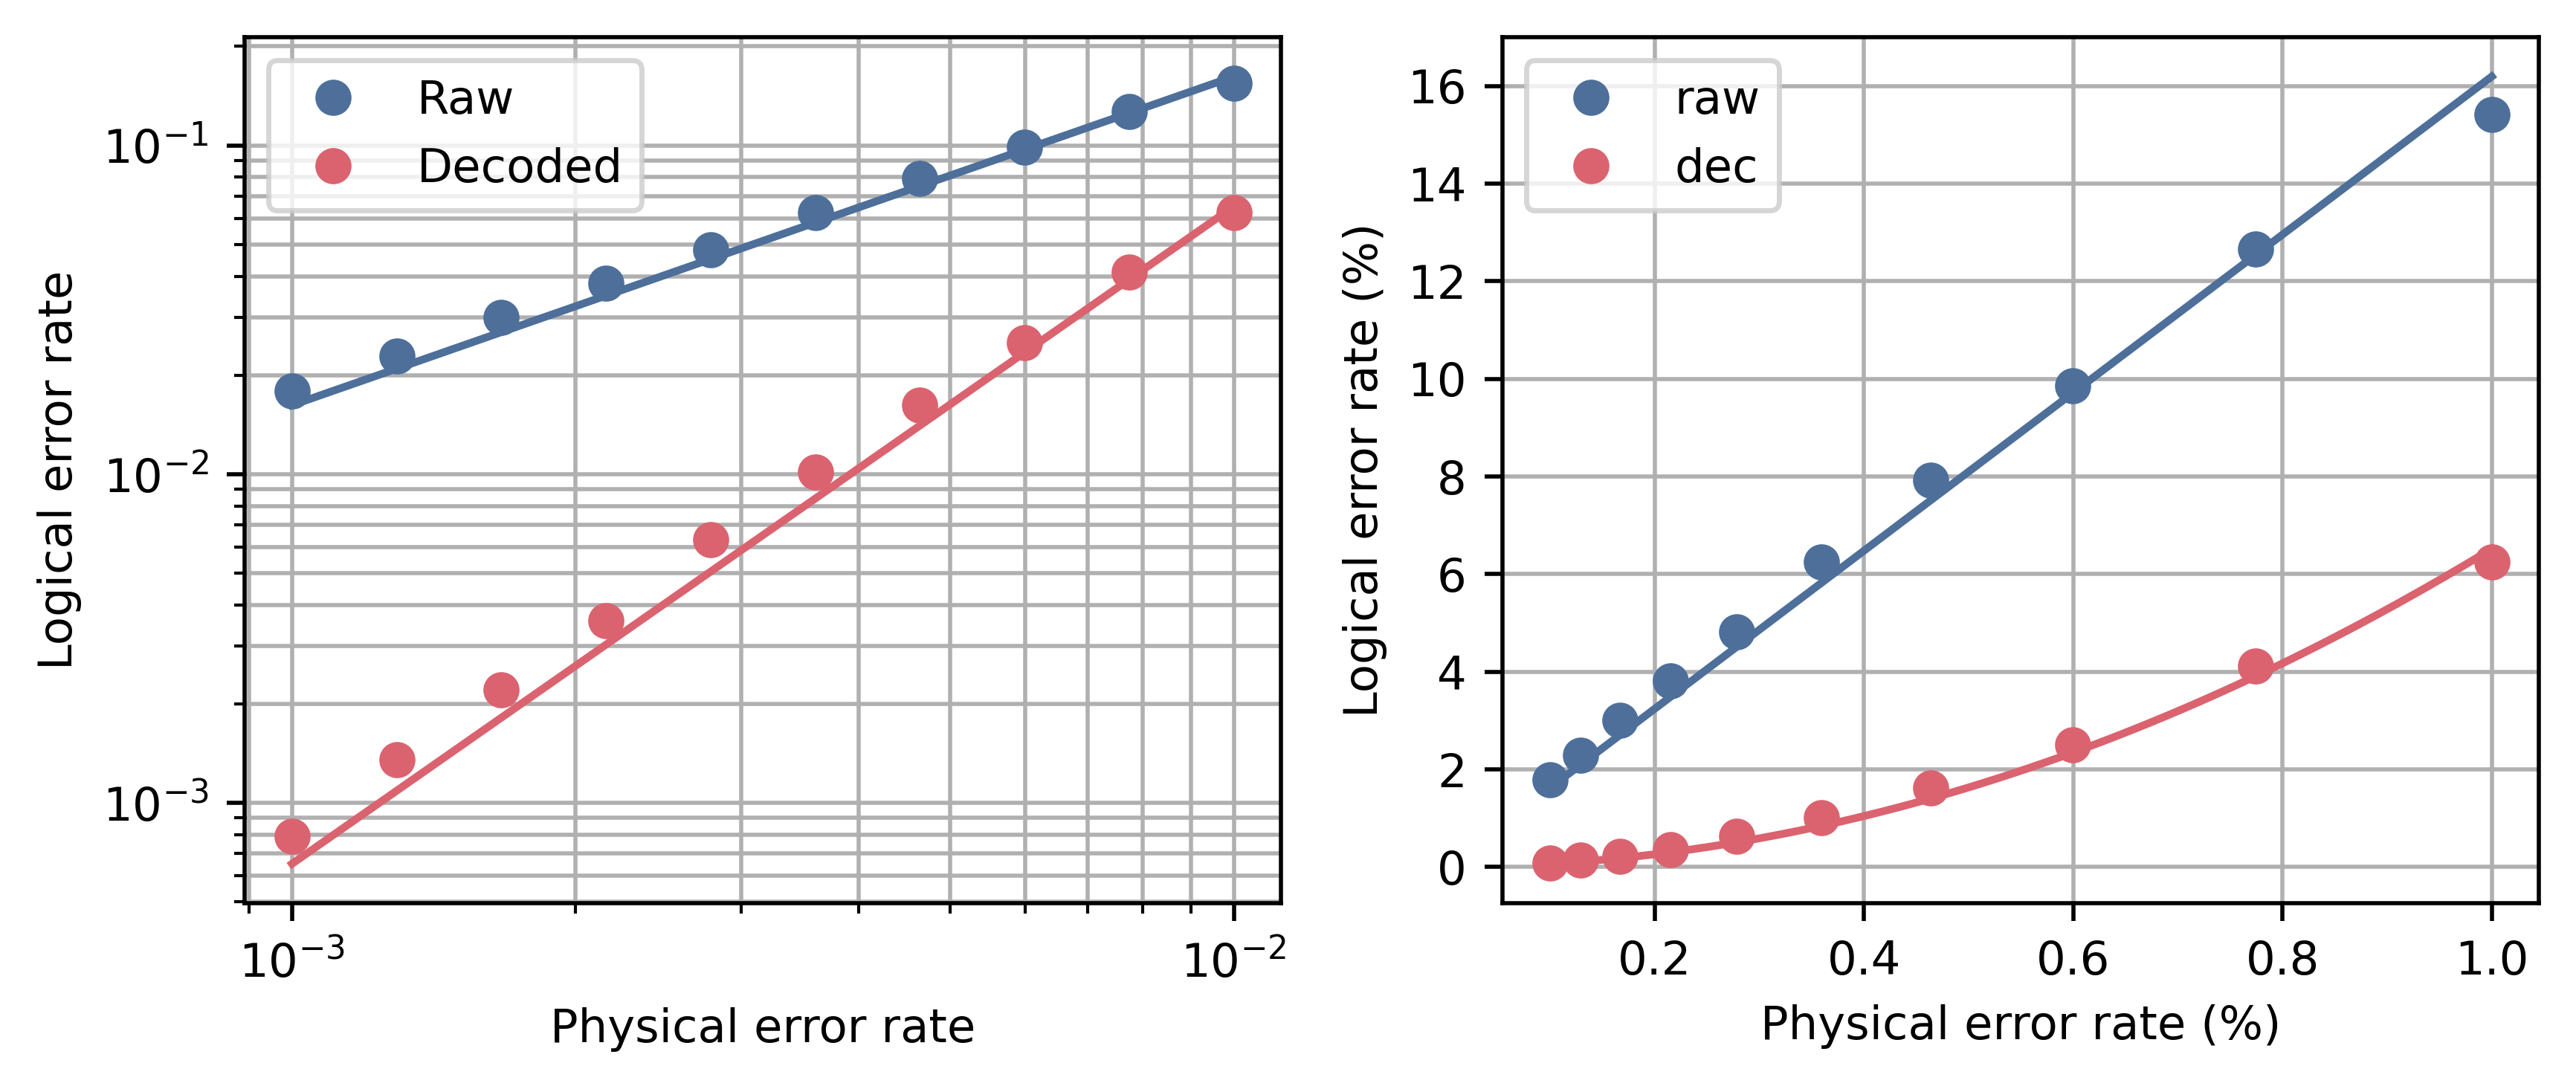

In [27]:
from scipy.optimize import curve_fit
from matplotlib.ticker import AutoMinorLocator, LogLocator

def fit_1_over_x(x, a):
    return a / x

def fit_1_over_x2(x, a):
    return a / x**2

def fit_1_over_x3(x, a):
    return a / x**3

improvement_factor = np.max(p_arr) / np.array(p_arr)
fit_params = {}
fit_covs = {}
function = {"raw": fit_1_over_x, "dec": fit_1_over_x2, "pst": fit_1_over_x3}
for mode in ["raw", "dec", "pst"]:
    popt, pcov = curve_fit(function[mode], improvement_factor, log_errors[mode])
    fit_params[mode] = popt
    fit_covs[mode] = pcov
improvement_factor_fine = np.logspace(np.min(np.log10(improvement_factor)), np.max(np.log10(improvement_factor)), 100)

default_colors = list(plt.rcParams['axes.prop_cycle'].by_key()['color'])

fig, axs = plt.subplots(1, 2, figsize=(7, 3), dpi=500)
for i, mode in enumerate(["raw", "dec"]): # , "pst"
    axs[0].plot(np.max(p_arr)/improvement_factor_fine, function[mode](improvement_factor_fine, *fit_params[mode]), color=default_colors[i])
    axs[0].plot(np.max(p_arr)/improvement_factor, log_errors[mode], 'o', label="Raw" if mode == "raw" else "Decoded", color=default_colors[i])
    axs[0].set_xscale('log')
    axs[0].set_yscale('log')
    axs[0].legend()
    axs[0].set_xlabel("Physical error rate")
    axs[0].set_ylabel("Logical error rate")

for i, mode in enumerate(["raw", "dec"]): # , "pst"
    axs[1].plot(100*np.max(p_arr)/np.array(improvement_factor_fine), 100*np.array(function[mode](improvement_factor_fine, *fit_params[mode])), color=default_colors[i])
    axs[1].plot(100*np.max(p_arr)/np.array(improvement_factor), 100*np.array(log_errors[mode]), 'o', label=mode, color=default_colors[i])
    axs[1].set_xscale('linear')
    axs[1].set_yscale('linear')
    axs[1].legend()
    axs[1].set_xlabel("Physical error rate (%)")
    axs[1].set_ylabel("Logical error rate (%)")

axs[0].grid(True, which='both')
axs[0].xaxis.set_minor_locator(LogLocator(base=10.0, subs='auto', numticks=50))
axs[1].grid(True)
plt.tight_layout()
plt.savefig("error_rates.png", dpi=1000)
plt.show()


# Find fault-tolerant syndrome extraction circuit

In [82]:
import itertools

code = "22TT"
n_qec_rounds = 3
stab_ext_mode = "parallel"
n = 12

incl_det_ids = range(len(stabilizers_22_TT_generic))
qb_coords = {}
for qb, coord in qubit_positions.items():
    qb_id = int(qb[1:]) - 1
    if qb[0] == "X":
        qb_id += 12
    if qb[0] == "Z":
        qb_id += 17
    qb_coords[qb_id] = (coord[0], coord[1])
measure_op = "XXXXXXXXXXXX"
log_op = "XIIIXIIIXIII"

def_order = [0, 1, 2, 3]
all_orders = list(itertools.permutations(def_order))
print(f"There are all_orders = {len(all_orders)} possible orders")
# all_order_selectors = list(itertools.product(range(len(all_orders)), repeat=10))

# Same schedule for all stabilizers
# Num valid circuits: d=2: 8, d=3: 0
# all_order_selectors = [[i for _ in range(len(stabilizers_22_TT_generic))] for i in range(len(all_orders))]

# Same schedule for X and same for Z
# 24 valid circuits of d=2
# 0 valid circuits of d=3
all_order_selectors_5_stabs = [[i for _ in range(5)] for i in range(len(all_orders))]
all_order_selectors = [all_order_selectors_5_stabs[i] + all_order_selectors_5_stabs[j] for i in range(len(all_orders)) for j in range(len(all_orders))]
print(all_order_selectors)

valid_orders_d2 = []
valid_orders_d3 = []
valid_circuits_d2 = []
valid_circuits_d3 = []
for i, order in enumerate(all_order_selectors):
    order_list = [all_orders[i] for i in order]
    stabilizers = order_stabs(stabilizers_22_TT_generic, order_list)
    try:
        stim_circ = get_stim_circ(stabilizers, n, n_qec_rounds, "XX", measure_op, qb_coords, incl_det_ids, stab_ext_mode)
        if len(stim_circ.detector_error_model().shortest_graphlike_error()) == 2:
            valid_circuits_d2.append(stim_circ)
            valid_orders_d2.append(order)
        if len(stim_circ.detector_error_model().shortest_graphlike_error()) == 3:
            valid_circuits_d3.append(stim_circ)
            valid_orders_d3.append(order)
    except:
        continue

    if i == 1000:
        break

print(f"There are {len(valid_circuits_d2)} syndrome extraction circuits with code distance 2")
print(f"There are {len(valid_circuits_d3)} syndrome extraction circuits with code distance 3")
print("Orders d=3:")
for o in valid_orders_d3:
    print(o)
print("Orders d=2:")
for o in valid_orders_d2:
    print(o)

There are all_orders = 24 possible orders
[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 1, 1, 1, 1, 1], [0, 0, 0, 0, 0, 2, 2, 2, 2, 2], [0, 0, 0, 0, 0, 3, 3, 3, 3, 3], [0, 0, 0, 0, 0, 4, 4, 4, 4, 4], [0, 0, 0, 0, 0, 5, 5, 5, 5, 5], [0, 0, 0, 0, 0, 6, 6, 6, 6, 6], [0, 0, 0, 0, 0, 7, 7, 7, 7, 7], [0, 0, 0, 0, 0, 8, 8, 8, 8, 8], [0, 0, 0, 0, 0, 9, 9, 9, 9, 9], [0, 0, 0, 0, 0, 10, 10, 10, 10, 10], [0, 0, 0, 0, 0, 11, 11, 11, 11, 11], [0, 0, 0, 0, 0, 12, 12, 12, 12, 12], [0, 0, 0, 0, 0, 13, 13, 13, 13, 13], [0, 0, 0, 0, 0, 14, 14, 14, 14, 14], [0, 0, 0, 0, 0, 15, 15, 15, 15, 15], [0, 0, 0, 0, 0, 16, 16, 16, 16, 16], [0, 0, 0, 0, 0, 17, 17, 17, 17, 17], [0, 0, 0, 0, 0, 18, 18, 18, 18, 18], [0, 0, 0, 0, 0, 19, 19, 19, 19, 19], [0, 0, 0, 0, 0, 20, 20, 20, 20, 20], [0, 0, 0, 0, 0, 21, 21, 21, 21, 21], [0, 0, 0, 0, 0, 22, 22, 22, 22, 22], [0, 0, 0, 0, 0, 23, 23, 23, 23, 23], [1, 1, 1, 1, 1, 0, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 2, 2, 2, 2, 2], [1, 1, 1, 1, 1, 3, 3, 3

In [ ]:
for order in valid_orders_d3:
    print(f"Order X = {all_orders[order[0]]}, order Z = {all_orders[order[5]]}")

def is_qubit_used_twice(stabilizers):
    for i in range(4):
        qbs = [stab[1][i] for stab in stabilizers if stab[0][i] != "I"]
        if len(qbs) != len(set(qbs)):
            return True
for order in valid_orders_d3:
    composed_order = [all_orders[order[0]] for _ in range(5)] + [all_orders[order[5]] for _ in range(5)]
    print(composed_order)
    stabs = order_stabs(stabilizers_22_TT_generic, composed_order)
    print(is_qubit_used_twice(stabs))


Order X = (0, 2, 1, 3), order Z = (1, 3, 0, 2)
Order X = (0, 2, 3, 1), order Z = (3, 1, 0, 2)
Order X = (1, 3, 0, 2), order Z = (0, 2, 1, 3)
Order X = (1, 3, 2, 0), order Z = (2, 0, 1, 3)
Order X = (2, 0, 1, 3), order Z = (1, 3, 2, 0)
Order X = (2, 0, 3, 1), order Z = (3, 1, 2, 0)
Order X = (3, 1, 0, 2), order Z = (0, 2, 3, 1)
Order X = (3, 1, 2, 0), order Z = (2, 0, 3, 1)
[(0, 2, 1, 3), (0, 2, 1, 3), (0, 2, 1, 3), (0, 2, 1, 3), (0, 2, 1, 3), (1, 3, 0, 2), (1, 3, 0, 2), (1, 3, 0, 2), (1, 3, 0, 2), (1, 3, 0, 2)]
True
[(0, 2, 3, 1), (0, 2, 3, 1), (0, 2, 3, 1), (0, 2, 3, 1), (0, 2, 3, 1), (3, 1, 0, 2), (3, 1, 0, 2), (3, 1, 0, 2), (3, 1, 0, 2), (3, 1, 0, 2)]
True
[(1, 3, 0, 2), (1, 3, 0, 2), (1, 3, 0, 2), (1, 3, 0, 2), (1, 3, 0, 2), (0, 2, 1, 3), (0, 2, 1, 3), (0, 2, 1, 3), (0, 2, 1, 3), (0, 2, 1, 3)]
True
[(1, 3, 2, 0), (1, 3, 2, 0), (1, 3, 2, 0), (1, 3, 2, 0), (1, 3, 2, 0), (2, 0, 1, 3), (2, 0, 1, 3), (2, 0, 1, 3), (2, 0, 1, 3), (2, 0, 1, 3)]
True
[(2, 0, 1, 3), (2, 0, 1, 3), (2, 0, 1, 3

In [ ]:
# # Estimate number of possible syndrome extraction circuits

# stabs = stabilizers_22_TT_generic
# valid_orders = []
# stab_id = {
#     "X1": 0,
#     "X2": 1,
#     "X3": 2,
#     "X4": 3,
#     "X5": 4,
#     "Z1": 5,
#     "Z2": 6,
#     "Z3": 7,
#     "Z4": 8,
#     "Z5": 9,
# }
# # S_X1
# orders = {}
# stop_search = False
# for order_X1 in all_orders:
#     orders["X1"] = order_X1
#     # S_X2
#     for order_X2 in all_orders:
#         stab_name = "X2"
#         orders[stab_name] = order_X2
#         is_valid_order = True
#         neighboring_stabs = ["X1"]
#         for i in range(4):
#             if any([stabs[stab_id[stab]][1][orders[stab][i]] == stabs[stab_id[stab_name]][1][orders[stab_name][i]] for stab in neighboring_stabs]):
#                 is_valid_order = False
#                 break
#         if not is_valid_order:
#             continue

#         # S_Z3
#         for order_Z3 in all_orders:
#             stab_name = "Z3"
#             orders[stab_name] = order_Z3
#             is_valid_order = True
#             neighboring_stabs = ["X1", "X2"]
#             for i in range(4):
#                 if any([stabs[stab_id[stab]][1][orders[stab][i]] == stabs[stab_id[stab_name]][1][orders[stab_name][i]] for stab in neighboring_stabs]):
#                     is_valid_order = False
#                     break
#             if not is_valid_order:
#                 continue

#             # S_X3
#             for order_X3 in all_orders:
#                 stab_name = "X3"
#                 orders[stab_name] = order_X3
#                 is_valid_order = True
#                 neighboring_stabs = ["X1", "X2", "Z3"]
#                 for i in range(4):
#                     if any([stabs[stab_id[stab]][1][orders[stab][i]] == stabs[stab_id[stab_name]][1][orders[stab_name][i]] for stab in neighboring_stabs]):
#                         is_valid_order = False
#                         break
#                 if not is_valid_order:
#                     continue

#                 # S_Z2
#                 for order_Z2 in all_orders:
#                     stab_name = "Z2"
#                     orders[stab_name] = order_Z2
#                     is_valid_order = True
#                     neighboring_stabs = ["X1", "X2", "Z3", "X3"]
#                     for i in range(4):
#                         if any([stabs[stab_id[stab]][1][orders[stab][i]] == stabs[stab_id[stab_name]][1][orders[stab_name][i]] for stab in neighboring_stabs]):
#                             is_valid_order = False
#                             break
#                     if not is_valid_order:
#                         continue

#                     # S_Z1
#                     for order_Z1 in all_orders:
#                         stab_name = "Z1"
#                         orders[stab_name] = order_Z1
#                         is_valid_order = True
#                         neighboring_stabs = ["X1", "X2", "Z3", "Z2"]
#                         for i in range(4):
#                             if any([stabs[stab_id[stab]][1][orders[stab][i]] == stabs[stab_id[stab_name]][1][orders[stab_name][i]] for stab in neighboring_stabs]):
#                                 is_valid_order = False
#                                 break
#                         if not is_valid_order:
#                             continue

#                         # S_Z4
#                         for order_Z4 in all_orders:
#                             stab_name = "Z4"
#                             orders[stab_name] = order_Z4
#                             is_valid_order = True
#                             neighboring_stabs = ["X2", "X3", "Z2", "Z3"]
#                             for i in range(4):
#                                 if any([stabs[stab_id[stab]][1][orders[stab][i]] == stabs[stab_id[stab_name]][1][orders[stab_name][i]] for stab in neighboring_stabs]):
#                                     is_valid_order = False
#                                     break
#                             if not is_valid_order:
#                                 continue

#                             # S_X4
#                             for order_X4 in all_orders:
#                                 stab_name = "X4"
#                                 orders[stab_name] = order_X4
#                                 is_valid_order = True
#                                 neighboring_stabs = ["X2", "X3", "Z3", "Z4"]
#                                 for i in range(4):
#                                     if any([stabs[stab_id[stab]][1][orders[stab][i]] == stabs[stab_id[stab_name]][1][orders[stab_name][i]] for stab in neighboring_stabs]):
#                                         is_valid_order = False
#                                         break
#                                 if not is_valid_order:
#                                     continue

#                                 # S_X5
#                                 for order_X5 in all_orders:
#                                     stab_name = "X5"
#                                     orders[stab_name] = order_X5
#                                     is_valid_order = True
#                                     neighboring_stabs = ["X1", "X3", "X4", "Z1", "Z4"]
#                                     for i in range(4):
#                                         if any([stabs[stab_id[stab]][1][orders[stab][i]] == stabs[stab_id[stab_name]][1][orders[stab_name][i]] for stab in neighboring_stabs]):
#                                             is_valid_order = False
#                                             break
#                                     if not is_valid_order:
#                                         continue

#                                     # S_Z5
#                                     for order_Z5 in all_orders:
#                                         stab_name = "Z5"
#                                         orders[stab_name] = order_Z5
#                                         is_valid_order = True
#                                         neighboring_stabs = ["X3", "X4", "Z3"]
#                                         for i in range(4):
#                                             if any([stabs[stab_id[stab]][1][orders[stab][i]] == stabs[stab_id[stab_name]][1][orders[stab_name][i]] for stab in neighboring_stabs]):
#                                                 is_valid_order = False
#                                                 break
#                                         if not is_valid_order:
#                                             continue
#                                         else:
#                                             valid_orders.append([order_X1, order_X2, order_X3, order_X4, order_X5, order_Z1, order_Z2, order_Z3, order_Z4, order_Z5])

#                                         if len(valid_orders) > 10000:
#                                             stop_search = True
#                                         if stop_search:
#                                             break
#                                     if stop_search:
#                                         break
#                                 if stop_search:
#                                     break
#                             if stop_search:
#                                 break
#                         if stop_search:
#                             break
#                     if stop_search:
#                         break
#                 if stop_search:
#                     break
#             if stop_search:
#                 break
#         if stop_search:
#             break
#     if stop_search:
#         break

# print(f"Found {len(valid_orders)} valid orders")

# No long-range couplers

In [ ]:
S_X1_no_lrc = [1,1,1,0,0,1,0,0,0,0,0,0, 0,0,0,0,0,0,0,0,0,0,0,0]
S_X2_no_lrc = [0,0,1,1,0,0,0,1,0,0,0,0, 0,0,0,0,0,0,0,0,0,0,0,0]
S_X3_no_lrc = [0,0,0,0,1,1,1,0,0,1,0,0, 0,0,0,0,0,0,0,0,0,0,0,0]
S_X4_no_lrc = [0,0,0,0,0,0,1,1,0,0,0,1, 0,0,0,0,0,0,0,0,0,0,0,0]
S_X5_no_lrc = [0,0,0,0,0,0,0,0,1,1,1,0, 0,0,0,0,0,0,0,0,0,0,0,0]
S_Z1_no_lrc = [0,0,0,0,0,0,0,0,0,0,0,0, 0,1,1,1,0,0,0,0,0,0,0,0]
S_Z2_no_lrc = [0,0,0,0,0,0,0,0,0,0,0,0, 1,0,0,0,1,1,0,0,0,0,0,0]
S_Z3_no_lrc = [0,0,0,0,0,0,0,0,0,0,0,0, 0,0,1,0,0,1,1,1,0,0,0,0]
S_Z4_no_lrc = [0,0,0,0,0,0,0,0,0,0,0,0, 0,0,0,0,1,0,0,0,1,1,0,0]
S_Z5_no_lrc = [0,0,0,0,0,0,0,0,0,0,0,0, 0,0,0,0,0,0,1,0,0,1,1,1]
stabs_no_lrc = [S_X1_no_lrc, S_X2_no_lrc, S_X3_no_lrc, S_X4_no_lrc, S_X5_no_lrc, S_Z1_no_lrc, S_Z2_no_lrc, S_Z3_no_lrc, S_Z4_no_lrc, S_Z5_no_lrc]
stab_matrix_no_lrc = np.array(stabs_no_lrc)
log_X1_no_lrc = [1,0,0,0,1,0,0,0,1,0,0,0, 0,0,0,0,0,0,0,0,0,0,0,0]
log_Z1_no_lrc = [0,0,0,0,0,0,0,0,0,0,0,0, 1,0,0,0,0,1,1,0,0,0,0,1]
log_X2_no_lrc = [1,0,0,0,0,1,1,0,0,0,0,1, 0,0,0,0,0,0,0,0,0,0,0,0]
log_Z2_no_lrc = [0,0,0,0,0,0,0,0,0,0,0,0, 0,0,0,1,0,0,0,1,0,0,0,1]

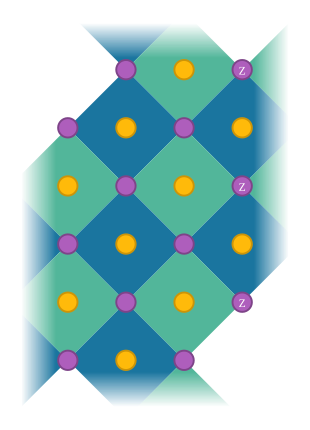

In [ ]:
draw_code(file_path, pauli_str=F2_to_xyz(log_Z2_no_lrc))

In [ ]:
is_valid_tableau(stab_matrix_no_lrc[0:-6], [(log_X1_no_lrc, log_Z1_no_lrc), (log_X2_no_lrc, log_Z2_no_lrc)])

d:\local-nobackup\git\qeclibrary\src\qeclib\qeclib\math\symplectic_form.py:275: UserWarning: The system is not fully defined, i.e. m + k < n
  warnings.warn("The system is not fully defined, i.e. m + k < n")


True

In [ ]:
find_distance(stab_matrix_no_lrc)

2